# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [ ]:
#!pip install mat73 h5py


In [2]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12


In [4]:
# 데이터 경로 설정
DATA_DIR = os.path.expanduser(
    '~/workspace/ess_data/archive'
)

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_mb:.1f} GB)")


데이터 경로 : /Users/jc/workspace/ess_data/archive
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [5]:
# Batch 1 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch1_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [7]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")


mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [8]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")


배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [9]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")


mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [10]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)


In [11]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()


DataFrame shape : (38811, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1190,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,2,1190,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,0,3,1190,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,0,4,1190,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,0,5,1190,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


In [12]:
# 기본 통계
df.describe().round(3)


,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [13]:
print("결측치 현황 : ")
print(df.isnull().sum())


결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [14]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")



배터리 셀 수   : 46
충전 정책 종류 : 23


## EDA(Basic)

### 1. Cycle Life 분포

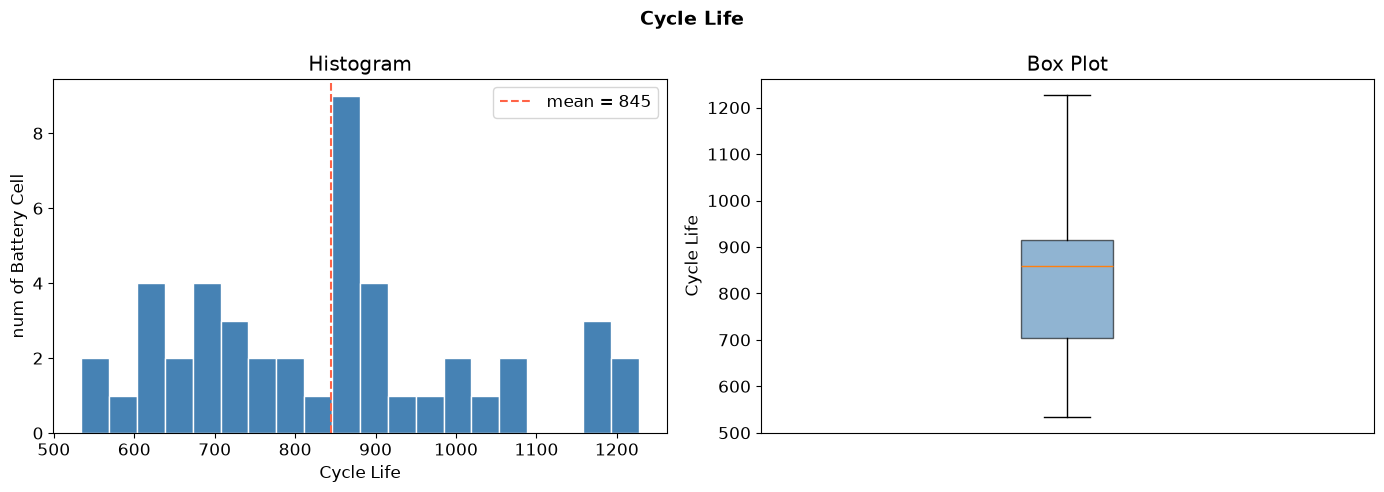

count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64


In [15]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))


[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

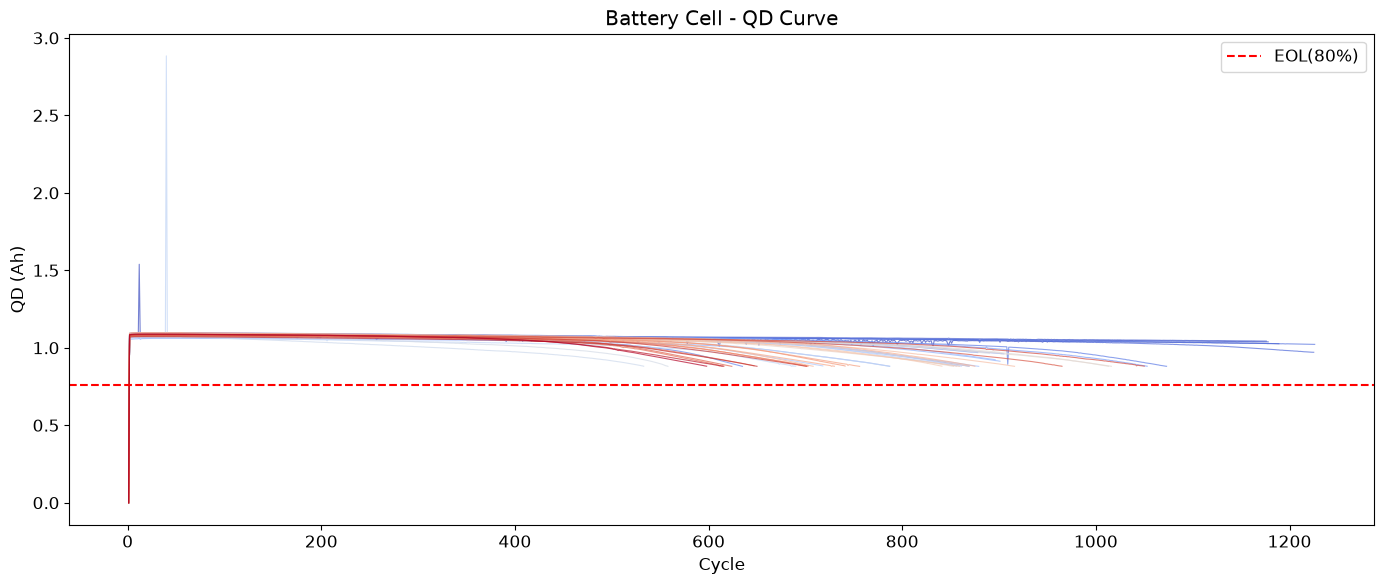

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()


[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

공칭 용량(nominal) : 1.0796 Ah
필터 범위          : 0.8637 ~ 1.2956 Ah
제거된 행 수       : 48 (0.12%)


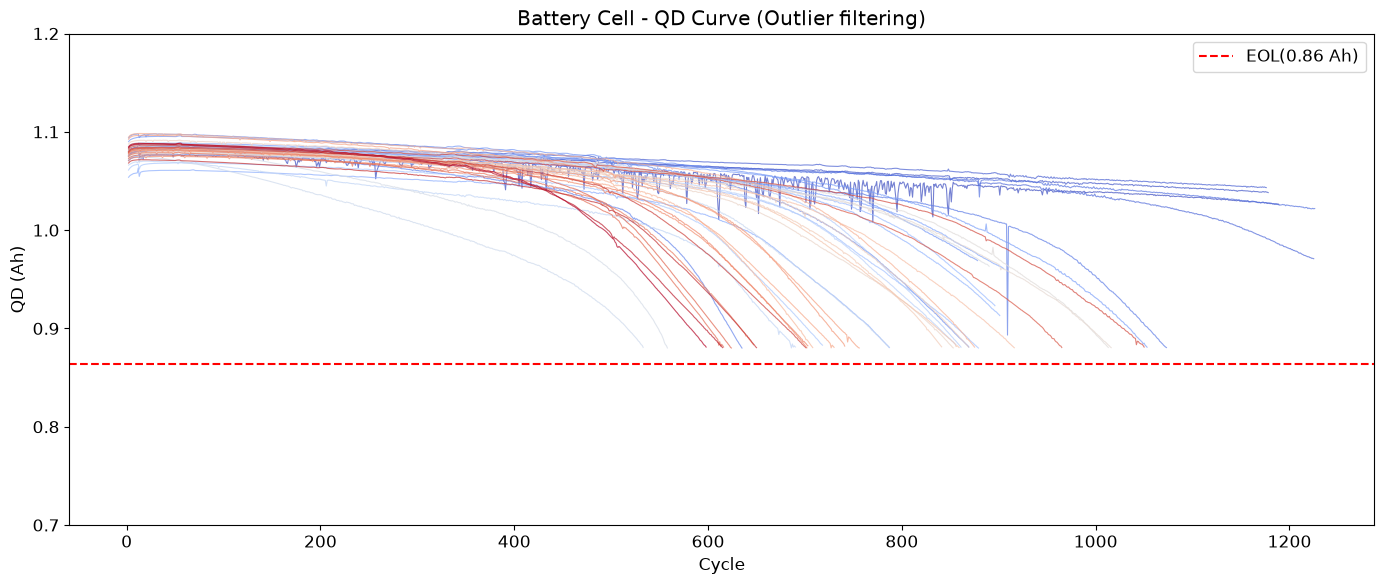

In [17]:
# Outlier 필터링 후 열화 곡선 

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=colors[i], linewidth=0.8, alpha=0.7)

ax.axhline(y=nominal * 0.8, color='red', linestyle='--',
           linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()


[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 다른 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

### 3. 내부 저항(IR) 변화 - 열화 지표

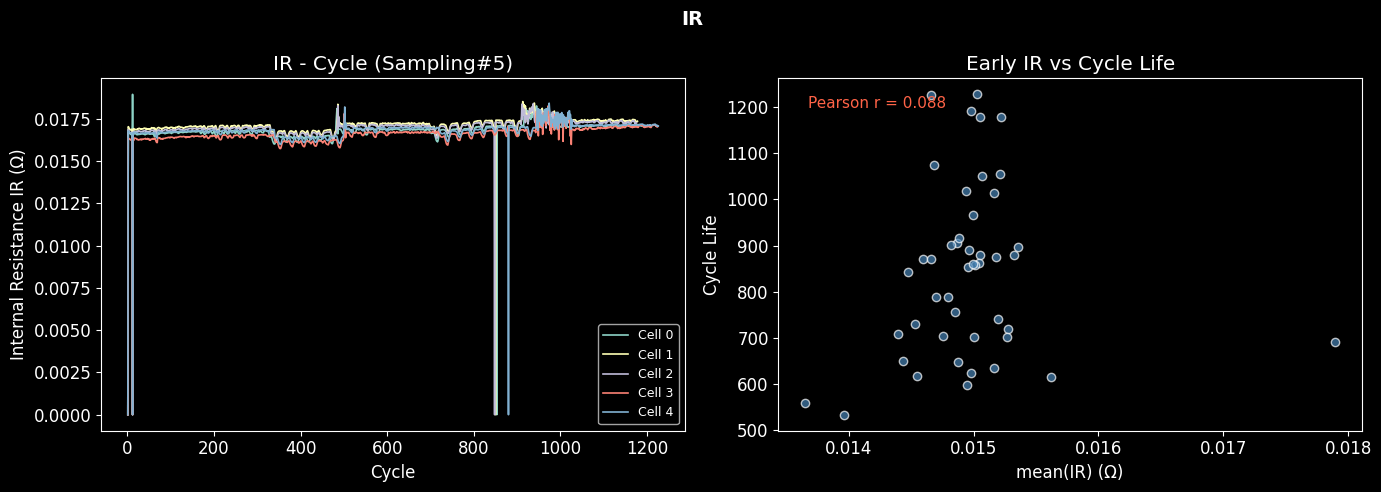

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


[plot] - Sampling
- 내부저항(IR)이 전체 구간에서 평탄함. 배터리가 열화될수록 IR이 증가해야 하는데 해당 샘플에서는 확인되지 않음 
    - 샘플링 배터리는 IR 변화가 용량 변화에 비해 상대적으로 적음 -> 흑연 음극 구조 특징 
    - 사이클 800~900 부근의 스파이크는 측정 노이즈 또는 셀 교체 시점으로 해석 가능 

[plot] - correlation 
- 상관계수가 0.088이고, scatter 분포를 통해 상관관계 전혀 없음 

[to modeling]
- IR 단독으로 target variable 설명할 수 없음 
- IR 변화율(ΔIR) 또는 다른 변수와의 조합/비교 통한 파생변수 고민 

### 4. 충전 정책(C-rate)과 수명의 관계

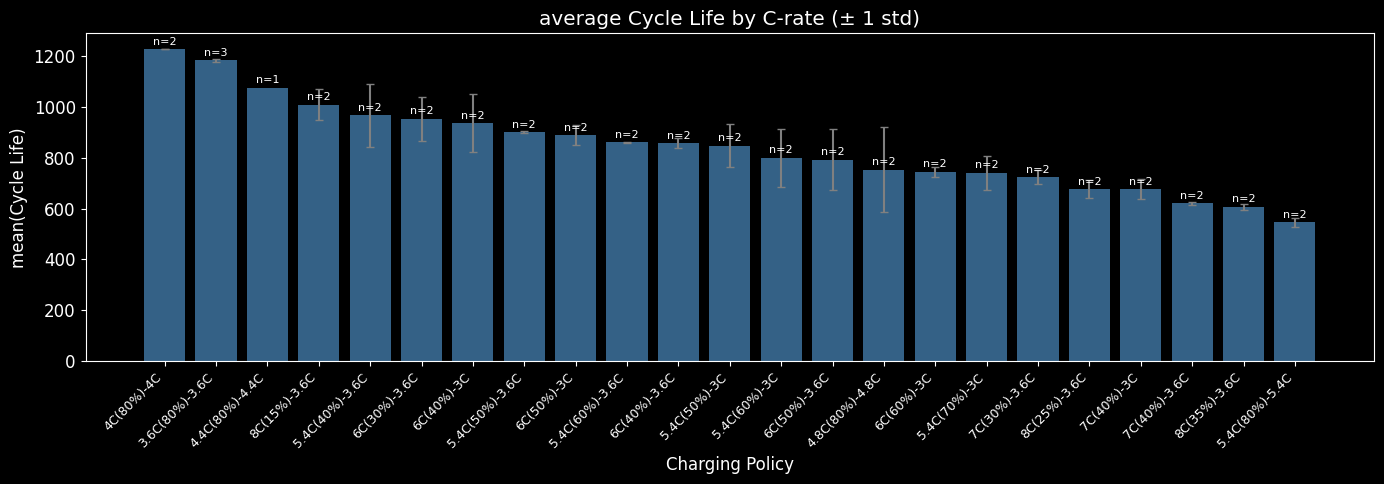

In [29]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


[remark] C-rate : 배터리 용량 대비 총전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `4C(80%)-4C`
    - `4C` : 1단계. 0% -> 80%까지 4C 속도로 충전 
    - `(80%)` : 전환 기준. 용량 80% 도달 시 속도 변경 
    - `4C` : 2단계. 나머지 20%는 4C 속도로 충전 
- 정책 비교 
    - `4C(80%)-4C` : 처음부터 끝까지 빠르게 
    - `4C(80%)-3.6C` : 2단계만 살짝 천천히 
    - `5.4C(80%)-5.4C` : 처음부터 끝까지 매우 빠르게 -> 수명 최단

[plot]
- 왼쪽(장수)에서 오른쪽(단명)으로 갈수록 C-rate 숫자가 커지는 경향 
    - 상위 구간 (cycle 1000~1200) : `4C(80%)-4C`, `3.6C(80%)-3.6C`
    - 중위 구간 (cycle 800~900)   : `6C(40%)-3C`, `5.4C(50%)-3.6C`
    - 하위 구간 (cycle 500~600)   : `8C(35%)-3.6C`, `5.4C(80%)-5.4C`
    - 낮은 C-rate은 천천히 충전할수록 수명이 길고, 높은 C-rate로 빠르게 충전할수록 수명이 짧음 
    - Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용 확인 
- 2단계 충전 전략 영향도 : `8C(15%)-3.6C` vs `8C(25%)-3.6C` 
    - 그래프에서는 전환 기준을 어떻게 가져가느냐에 따라 배터리 수명에 영향을 주는 것으로 보임 
    - 그러나 샘플이 정책당 2건 밖에 되지 않으므로 "경향성" 수준으로 해석해야 함 

[to modeling]
- 충전 정책은 배터리 수명에 영향을 미치고 있음 
- 특정 정책에서는 편차가 존재하므로 추가 변수 고려 필요

### 5. 상관관계 히트맵

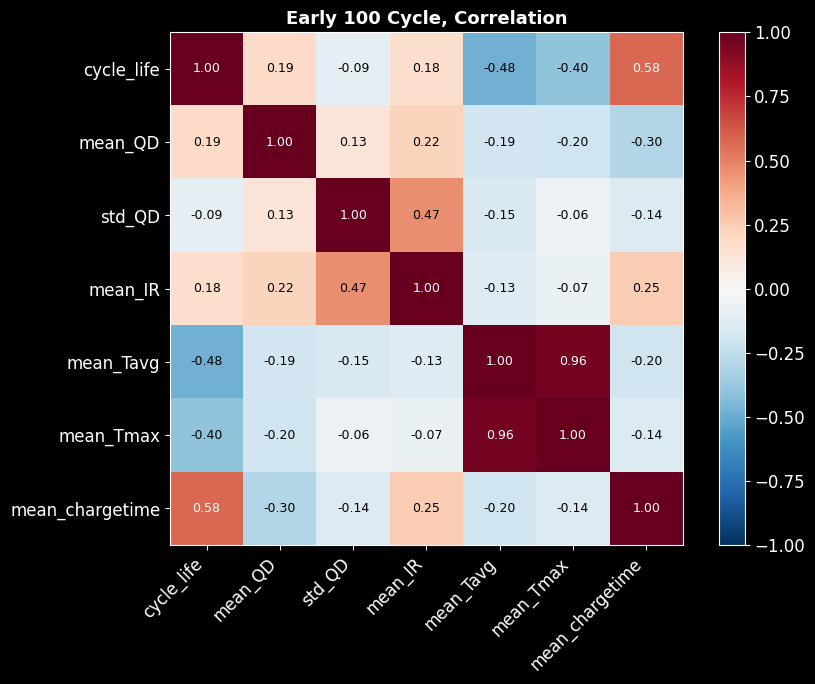


[cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD            0.193
mean_IR            0.177
std_QD            -0.090
Name: cycle_life, dtype: float64


In [30]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))


[correlation]
- `mean_chargetime` : 충전 시간이 길수록 수명이 길어짐 -> C-rate과 직결. 천천히 충전(긴 충전시간) = 낮은 C-rate = 긴 수명으로 앞에서 확인 
- `mean_Tavg`, `mean_Tmax` : 온도가 높을수록 수명이 짧아짐. 빠른 충전(높은 C-rate)이 발열을 유발하고 이것이 열화를 가속화하는 인과관계 확인 
- `mean_Tavg` vs `mean_Tmax` : 다중공선성(0.96) 

[to modeling]
- 선형 관계 일부분 확인 가능 
- 비선형 패턴까지 추가 확인 필요

---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.

DAY1 - EDA

1. cycle_life 분포는 어떻게 생겼는가?

In [18]:
import numpy as np
import pandas as pd

def find_rough_knee(sub, smooth_window=30, slope_window=20, factor=3):
    sub = (
        sub[['cycle', 'QD']]
        .dropna()
        .sort_values('cycle')
        .copy()
    )

    # 초기 스파이크 영향을 줄이기 위해 QD 평활화
    sub['QD_smooth'] = (
        sub['QD']
        .rolling(
            window=smooth_window,
            center=True,
            min_periods=5
        )
        .median()
    )

    # 최근 slope_window 사이클 동안의 QD 감소 속도
    sub['QD_slope'] = (
        sub['QD_smooth'].diff(slope_window)
        / sub['cycle'].diff(slope_window)
    )

    # 초기 안정 구간의 일반적인 열화 속도
    baseline = sub.loc[
        sub['cycle'].between(50, 150),
        'QD_slope'
    ].median()

    # 초기 감소 속도의 factor배보다 빠르게 감소하면 가속 열화로 판단
    baseline_rate = max(abs(baseline), 1e-5)
    threshold = -factor * baseline_rate

    candidates = sub[
        (sub['cycle'] > 150) &
        (sub['QD_slope'] < threshold)
    ]

    if candidates.empty:
        return np.nan

    return int(candidates.iloc[0]['cycle'])


In [19]:
knee_records = []

for cell_id, sub in df.groupby('cell_id'):
    knee_cycle = find_rough_knee(sub)

    knee_records.append({
        'cell_id': cell_id,
        'cycle_life': sub['cycle_life'].iloc[0],
        'rough_knee_cycle': knee_cycle
    })

knee_df = pd.DataFrame(knee_records)

display(knee_df)


,cell_id,cycle_life,rough_knee_cycle
0,0,1190,164
1,1,1179,484
2,2,1177,485
3,3,1226,499
4,4,1227,447
5,5,1074,509
6,6,636,431
7,7,870,516
8,8,879,445
9,9,1054,384


In [20]:
knee_df.sort_values('rough_knee_cycle').head(10)


,cell_id,cycle_life,rough_knee_cycle
0,0,1190,164
38,38,617,245
35,35,703,269
17,17,857,274
45,45,599,274
34,34,742,280
39,39,625,283
14,14,880,294
15,15,719,294
37,37,648,304


In [21]:
knee_df[
    ['rough_knee_cycle', 'cycle_life']
].corr().round(3)


,rough_knee_cycle,cycle_life
rough_knee_cycle,1.000,0.321
cycle_life,0.321,1.000


In [22]:
import numpy as np
import pandas as pd

from scipy.stats import skew, kurtosis


In [23]:
def get_cycle_field(cell, cycle_number, field):
    """
    특정 셀의 특정 사이클에서 원하는 변수를 가져옴

    cycle_number=10  → 실제 10번째 사이클
    field='Qdlin'    → 보간된 방전 용량
    """
    idx = cycle_number - 1
    cycles_raw = cell['cycles']

    # mat73의 dict-of-lists 구조
    if isinstance(cycles_raw, dict):
        return cycles_raw[field][idx]

    # list-of-dicts 구조
    return cycles_raw[idx][field]


In [24]:
dq_curves = {}
feature_records = []

for cell_id, cell in enumerate(batch):
    q10 = get_cycle_field(
        cell,
        cycle_number=10,
        field='Qdlin'
    )

    q100 = get_cycle_field(
        cell,
        cycle_number=100,
        field='Qdlin'
    )

    # 데이터가 없는 셀은 제외
    if q10 is None or q100 is None:
        print(f'Cell {cell_id}: Qdlin 데이터 없음')
        continue

    voltage = np.asarray(cell['Vdlin']).ravel()
    q10 = np.asarray(q10, dtype=float).ravel()
    q100 = np.asarray(q100, dtype=float).ravel()

    # 길이 확인
    if not (
        len(voltage) == len(q10) == len(q100)
    ):
        print(f'Cell {cell_id}: 배열 길이 불일치')
        continue

    # ΔQ100-10(V)
    delta_q = q100 - q10

    # 유효값만 통계 계산
    valid_delta_q = delta_q[np.isfinite(delta_q)]

    if len(valid_delta_q) == 0:
        continue

    cycle_life = int(
        np.asarray(cell['cycle_life']).squeeze()
    )

    # 그래프용 데이터 저장
    dq_curves[cell_id] = {
        'voltage': voltage,
        'delta_q': delta_q
    }

    # 모델에 사용할 수 있는 통계 피처
    delta_q_variance = np.var(valid_delta_q)

    feature_records.append({
        'cell_id': cell_id,
        'cycle_life': cycle_life,

        'dq_mean': np.mean(valid_delta_q),
        'dq_std': np.std(valid_delta_q),
        'dq_variance': delta_q_variance,
        'dq_log_variance': np.log10(
            delta_q_variance + 1e-12
        ),
        'dq_min': np.min(valid_delta_q),
        'dq_max': np.max(valid_delta_q),
        'dq_range': (
            np.max(valid_delta_q)
            - np.min(valid_delta_q)
        ),
        'dq_abs_mean': np.mean(
            np.abs(valid_delta_q)
        ),
        'dq_skew': skew(valid_delta_q),
        'dq_kurtosis': kurtosis(valid_delta_q)
    })

dq_feature_df = pd.DataFrame(feature_records)

display(dq_feature_df.head())
print('분석된 셀 수:', len(dq_feature_df))


,cell_id,cycle_life,dq_mean,dq_std,dq_variance,dq_log_variance,dq_min,dq_max,dq_range,dq_abs_mean,dq_skew,dq_kurtosis
0,0,1190,-0.002873,0.003109,0.000010,-5.014861,-0.008460,0.000768,0.009228,0.002955,-0.532058,-1.348312
1,1,1179,-0.004100,0.003112,0.000010,-5.013960,-0.011004,-0.000088,0.010916,0.004100,-0.429375,-1.029116
2,2,1177,-0.004487,0.004281,0.000018,-4.737000,-0.017216,0.000013,0.017229,0.004487,-1.080194,0.348637
3,3,1226,-0.007456,0.006007,0.000036,-4.442613,-0.018961,0.000182,0.019143,0.007468,-0.439050,-1.095416
4,4,1227,-0.005750,0.004744,0.000023,-4.647744,-0.013958,0.000046,0.014004,0.005751,-0.362548,-1.333831


분석된 셀 수: 46


In [25]:
q1 = dq_feature_df['cycle_life'].quantile(0.25)
q3 = dq_feature_df['cycle_life'].quantile(0.75)

print(f'하위 25% 기준: {q1:.1f}사이클 이하')
print(f'상위 25% 기준: {q3:.1f}사이클 이상')


하위 25% 기준: 703.2사이클 이하
상위 25% 기준: 914.2사이클 이상


In [26]:
dq_feature_df['life_group'] = np.select(
    [
        dq_feature_df['cycle_life'] <= q1,
        dq_feature_df['cycle_life'] >= q3
    ],
    [
        'Relative short-life',
        'Relative long-life'
    ],
    default='Middle'
)

dq_feature_df['life_group'].value_counts()


life_group
Middle                 22
Relative long-life     12
Relative short-life    12
Name: count, dtype: int64

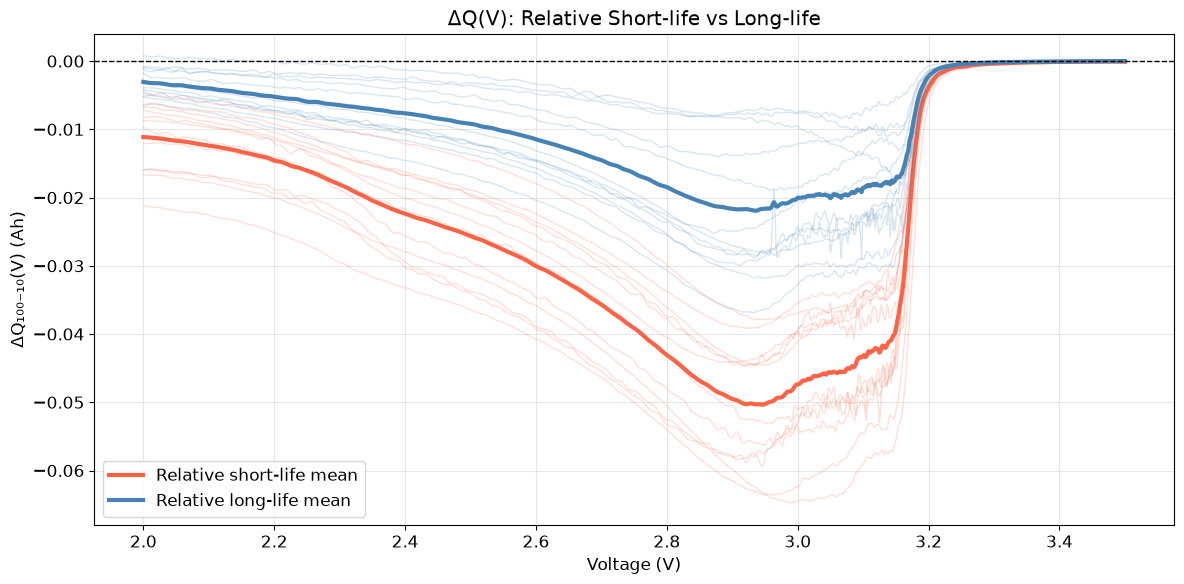

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

group_colors = {
    'Relative short-life': 'tomato',
    'Relative long-life': 'steelblue'
}

for group_name, color in group_colors.items():
    cell_ids = dq_feature_df.loc[
        dq_feature_df['life_group'] == group_name,
        'cell_id'
    ]

    group_curves = []

    for cell_id in cell_ids:
        curve = dq_curves[cell_id]

        ax.plot(
            curve['voltage'],
            curve['delta_q'],
            color=color,
            alpha=0.2,
            linewidth=1
        )

        group_curves.append(curve['delta_q'])

    # 그룹 평균 ΔQ(V)
    group_curves = np.vstack(group_curves)
    mean_curve = np.nanmean(group_curves, axis=0)

    reference_voltage = dq_curves[
        cell_ids.iloc[0]
    ]['voltage']

    ax.plot(
        reference_voltage,
        mean_curve,
        color=color,
        linewidth=3,
        label=f'{group_name} mean'
    )

ax.axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1
)

ax.set_xlabel('Voltage (V)')
ax.set_ylabel('ΔQ₁₀₀₋₁₀(V) (Ah)')
ax.set_title('ΔQ(V): Relative Short-life vs Long-life')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [28]:
feature_columns = [
    'dq_mean',
    'dq_std',
    'dq_variance',
    'dq_log_variance',
    'dq_min',
    'dq_max',
    'dq_range',
    'dq_abs_mean',
    'dq_skew',
    'dq_kurtosis'
]

group_feature_summary = (
    dq_feature_df[
        dq_feature_df['life_group'] != 'Middle'
    ]
    .groupby('life_group')[feature_columns]
    .agg(['mean', 'median'])
    .round(5)
)

display(group_feature_summary)


dq_mean            dq_std          dq_variance           \
                        mean   median     mean   median        mean   median   
life_group                                                                     
Relative long-life  -0.00967 -0.01129  0.00747  0.00867     0.00006  0.00008   
Relative short-life -0.02391 -0.02257  0.01688  0.01633     0.00029  0.00027   

                    dq_log_variance            dq_min            dq_max  \
                               mean   median     mean   median     mean   
life_group                                                                
Relative long-life         -4.33658 -4.12520 -0.02331 -0.02684  0.00008   
Relative short-life        -3.55836 -3.57731 -0.05092 -0.04893 -0.00004   

                             dq_range          dq_abs_mean           dq_skew  \
                      median     mean   median        mean   median     mean   
life_group                                                                     
Relative long-life   0.00002  0.02340  0.02697     0.00968  0.01130 -0.37664   
Relative short-life -0.00003  0.05089  0.04882     0.02391  0.02257 -0.07887   

                             dq_kurtosis           
                      median        mean   median  
life_group                                         
Relative long-life  -0.35071    -1.09462 -1.23605  
Relative short-life -0.09233    -1.26485 -1.28484

In [29]:
pearson_corr = (
    dq_feature_df[
        ['cycle_life'] + feature_columns
    ]
    .corr(method='pearson')['cycle_life']
    .drop('cycle_life')
)

spearman_corr = (
    dq_feature_df[
        ['cycle_life'] + feature_columns
    ]
    .corr(method='spearman')['cycle_life']
    .drop('cycle_life')
)

correlation_result = pd.DataFrame({
    'pearson': pearson_corr,
    'spearman': spearman_corr
})

correlation_result['max_abs_corr'] = (
    correlation_result[
        ['pearson', 'spearman']
    ]
    .abs()
    .max(axis=1)
)

correlation_result = correlation_result.sort_values(
    'max_abs_corr',
    ascending=False
)

display(correlation_result.round(3))


,pearson,spearman,max_abs_corr
dq_std,-0.894,-0.871,0.894
dq_log_variance,-0.886,-0.871,0.886
dq_range,-0.882,-0.850,0.882
dq_min,0.882,0.850,0.882
dq_variance,-0.838,-0.871,0.871
dq_mean,0.854,0.828,0.854
dq_abs_mean,-0.854,-0.828,0.854
dq_skew,-0.585,-0.556,0.585
dq_kurtosis,0.304,0.219,0.304
dq_max,0.264,0.195,0.264


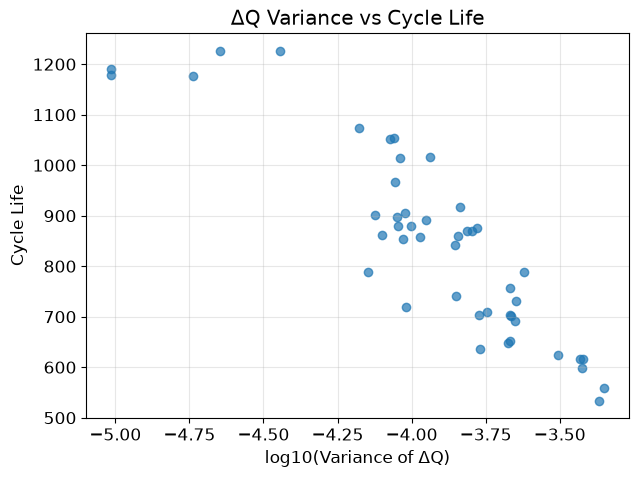

In [30]:
plt.figure(figsize=(7, 5))

plt.scatter(
    dq_feature_df['dq_log_variance'],
    dq_feature_df['cycle_life'],
    alpha=0.7
)

plt.xlabel('log10(Variance of ΔQ)')
plt.ylabel('Cycle Life')
plt.title('ΔQ Variance vs Cycle Life')
plt.grid(alpha=0.3)

plt.show()


<!-- CODEX_BATCH123_EDA_START -->
# 6. Batch 1·2·3 통합 EDA와 회귀 모델 설계

이 섹션은 **초기 100사이클만으로 `cycle_life`를 예측하는 회귀 문제**를 대상으로 한다. 분석 단위는 개별 배터리 셀이며, 사이클별 행을 그대로 학습에 넣지 않는다.

### 분석 목적

1. Batch 1에서 발견한 관계가 Batch 2·3에서도 유지되는지 확인한다.
2. 초기 100사이클에서 계산할 수 있고, 새로운 배치에서도 방향이 유지되는 피처를 선택한다.
3. Batch 1은 탐색/학습, Batch 2는 피처·모델 선택, Batch 3은 최종 테스트로 분리해 데이터 누수를 방지한다.

> **배치 정의:** Batch 1=`2017-05-12`, Batch 2=`2018-02-20`, Batch 3=`2018-04-12` 파일을 사용한다. `2018-04-03_varcharge` 파일은 셀이 2개뿐인 별도 가변충전 실험이므로 세 배치 비교에서 제외한다.


In [52]:
from pathlib import Path
import re

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew, spearmanr

PROJECT_DIR = Path('/Users/jc/workspace/ess_data')
ARCHIVE_DIR = PROJECT_DIR / 'archive'
BATCH_FILES = {
    'Batch 1': ARCHIVE_DIR / '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'Batch 2': ARCHIVE_DIR / '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'Batch 3': ARCHIVE_DIR / '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}

def _deref(h5, dataset, row):
    return h5[dataset[row, 0]]

def _read_string(h5, dataset, row):
    values = np.asarray(_deref(h5, dataset, row)).ravel()
    return ''.join(chr(int(v)) for v in values if int(v))

def _safe_stat(values, fn):
    values = np.asarray(values, dtype=float).ravel()
    values = values[np.isfinite(values)]
    return float(fn(values)) if values.size else np.nan

def _parse_policy(policy):
    # Batch 2·3의 동일 정책에는 -newstructure 접미사가 붙어 있다.
    policy = policy.removesuffix('-newstructure')
    match = re.fullmatch(r'([0-9.]+)C\(([0-9.]+)%\)-([0-9.]+)C', policy)
    if not match:
        return {k: np.nan for k in
                ['policy_c1', 'policy_soc', 'policy_c2', 'policy_weighted_c', 'policy_gap']}
    c1, soc_percent, c2 = map(float, match.groups())
    soc = soc_percent / 100
    return {
        'policy_c1': c1, 'policy_soc': soc, 'policy_c2': c2,
        'policy_weighted_c': c1 * soc + c2 * (1 - soc),
        'policy_gap': c1 - c2,
    }

def _add_series_features(row, prefix, cycles, values):
    cycles = np.asarray(cycles, dtype=float).ravel()
    values = np.asarray(values, dtype=float).ravel()
    mask = (cycles >= 10) & (cycles <= 100) & np.isfinite(values)
    x, y = cycles[mask], values[mask]
    row[f'{prefix}_mean'] = _safe_stat(y, np.mean)
    row[f'{prefix}_std'] = _safe_stat(y, np.std)
    row[f'{prefix}_median'] = _safe_stat(y, np.median)
    if len(x) >= 3 and np.ptp(x) > 0:
        slope, intercept = np.polyfit(x, y, 1)
        row[f'{prefix}_slope'] = float(slope)
        row[f'{prefix}_resid_std'] = float(np.std(y - (slope * x + intercept)))
    else:
        row[f'{prefix}_slope'] = row[f'{prefix}_resid_std'] = np.nan
    start = values[(cycles >= 10) & (cycles <= 20)]
    end = values[(cycles >= 91) & (cycles <= 100)]
    row[f'{prefix}_start'] = _safe_stat(start, np.median)
    row[f'{prefix}_end'] = _safe_stat(end, np.median)
    row[f'{prefix}_delta'] = row[f'{prefix}_end'] - row[f'{prefix}_start']

def _add_delta_q_features(row, voltage, q10, q100):
    voltage = np.asarray(voltage, dtype=float).ravel()
    q10 = np.asarray(q10, dtype=float).ravel()
    q100 = np.asarray(q100, dtype=float).ravel()
    valid = np.isfinite(voltage) & np.isfinite(q10) & np.isfinite(q100)
    voltage, dq = voltage[valid], (q100 - q10)[valid]
    order = np.argsort(voltage)
    voltage, dq = voltage[order], dq[order]
    variance = np.var(dq)
    row.update({
        'dq_mean': np.mean(dq), 'dq_std': np.std(dq),
        'dq_log_variance': np.log10(variance + 1e-12),
        'dq_min': np.min(dq), 'dq_max': np.max(dq),
        'dq_abs_mean': np.mean(np.abs(dq)),
        'dq_skew': skew(dq), 'dq_kurtosis': kurtosis(dq),
    })
    for low, high in [(2.0, 2.6), (2.6, 2.8), (2.8, 3.1), (3.1, 3.2), (3.2, 3.5)]:
        mask = (voltage >= low) & (voltage < high)
        label = f'{low:.1f}_{high:.1f}'.replace('.', 'p')
        row[f'dq_abs_mean_{label}'] = _safe_stat(dq[mask], lambda z: np.mean(np.abs(z)))

def extract_batch_features(path, batch_name):
    records = []
    with h5py.File(path, 'r') as h5:
        batch = h5['batch']
        for cell_id in range(batch['cycle_life'].shape[0]):
            row = {'batch': batch_name, 'cell_id': cell_id}
            row['cycle_life'] = float(np.asarray(_deref(h5, batch['cycle_life'], cell_id)).squeeze())
            row['policy'] = _read_string(h5, batch['policy_readable'], cell_id)
            row.update(_parse_policy(row['policy']))

            summary = _deref(h5, batch['summary'], cell_id)
            cycles = np.asarray(summary['cycle']).ravel()
            qd = np.asarray(summary['QDischarge']).ravel()
            qc = np.asarray(summary['QCharge']).ravel()
            ir = np.asarray(summary['IR']).ravel()
            tavg = np.asarray(summary['Tavg']).ravel()
            tmax = np.asarray(summary['Tmax']).ravel()
            tmin = np.asarray(summary['Tmin']).ravel()
            chargetime = np.asarray(summary['chargetime']).ravel()
            for prefix, values in {
                'qd': qd, 'qc': qc, 'ir': ir, 'tavg': tavg, 'tmax': tmax,
                'chargetime': chargetime, 'temp_gap': tmax - tavg,
                'temp_span': tmax - tmin,
            }.items():
                _add_series_features(row, prefix, cycles, values)

            cycles_group = _deref(h5, batch['cycles'], cell_id)
            qdlin_refs = cycles_group['Qdlin']
            if qdlin_refs.shape[0] < 100:
                continue
            q10 = np.asarray(h5[qdlin_refs[9, 0]]).ravel()
            q100 = np.asarray(h5[qdlin_refs[99, 0]]).ravel()
            voltage = np.asarray(_deref(h5, batch['Vdlin'], cell_id)).ravel()
            _add_delta_q_features(row, voltage, q10, q100)
            records.append(row)
    return pd.DataFrame(records)


,cells_extracted,cells_with_target,min,max,mean,median,std,target_missing,policy_count
batch,,,,,,,,,
Batch 1,46,46,534.0,1227.0,844.7,858.5,184.6,0,23
Batch 2,47,39,392.0,1186.0,565.7,472.0,222.2,8,20
Batch 3,46,44,541.0,1935.0,1059.7,1005.5,313.9,2,8


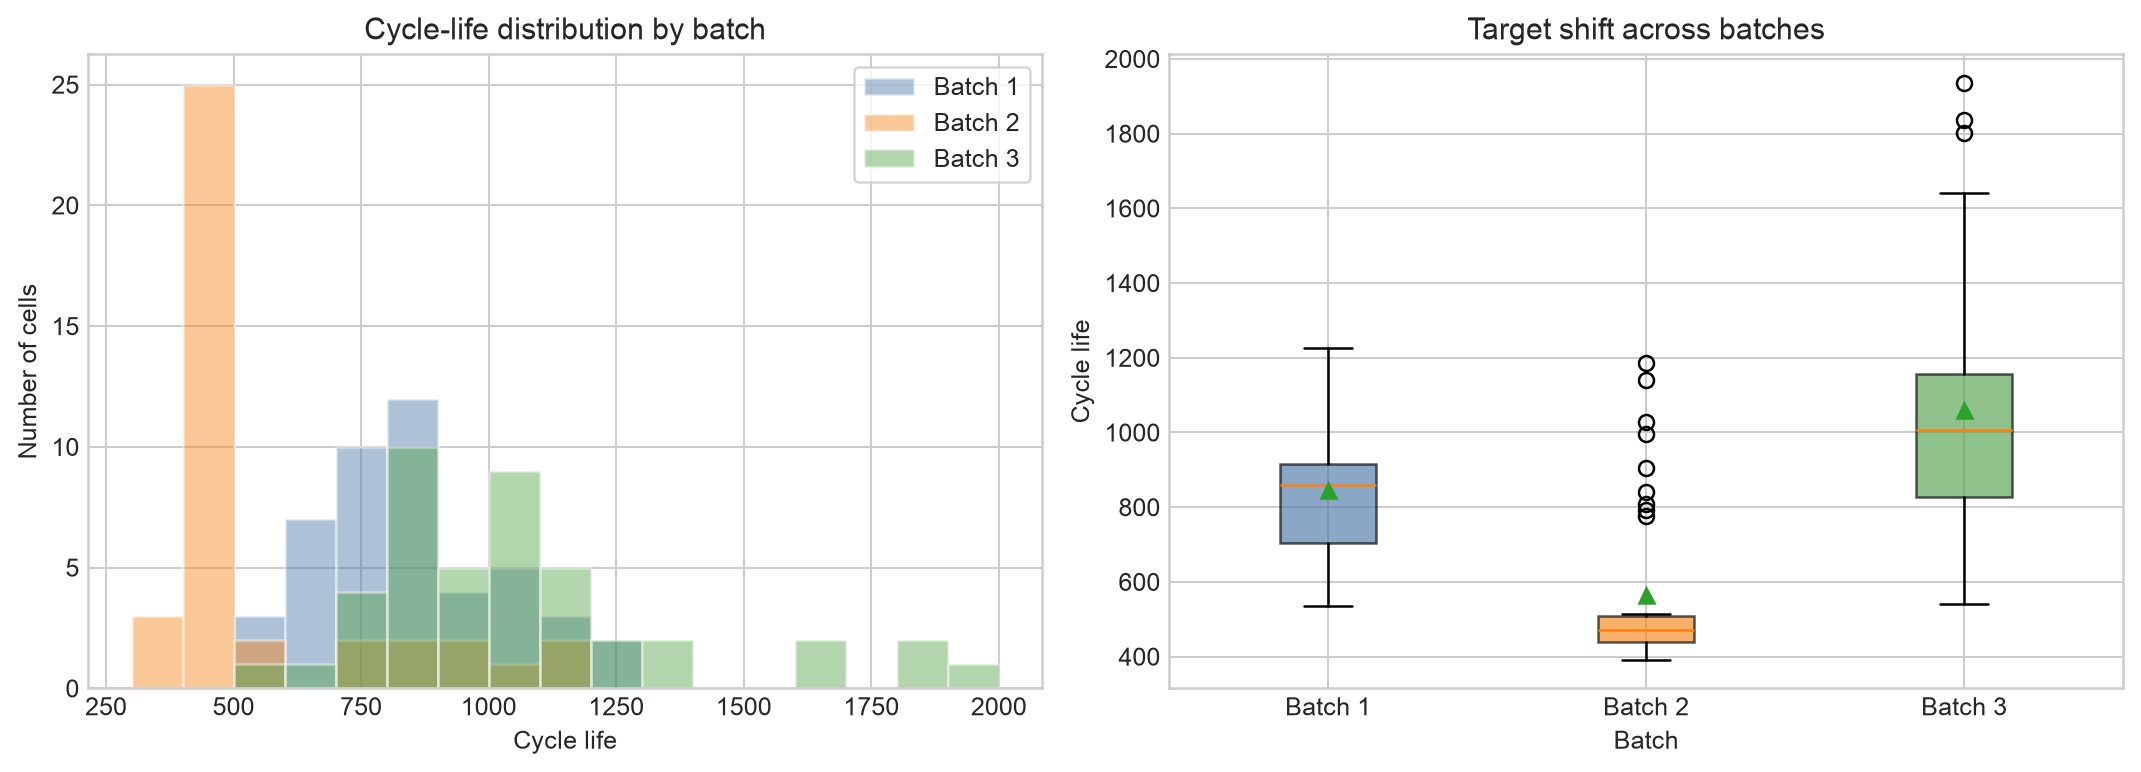

In [53]:
batch123_df = pd.concat(
    [extract_batch_features(path, batch) for batch, path in BATCH_FILES.items()],
    ignore_index=True,
)

# cycle_life가 NaN인 셀은 피처 표에는 보존하되 지도학습에서는 제외한다.
labeled_df = batch123_df[batch123_df['cycle_life'].notna()].copy()
batch_summary = batch123_df.groupby('batch')['cycle_life'].agg(
    cells_extracted='size', cells_with_target='count', min='min', max='max',
    mean='mean', median='median', std='std'
)
batch_summary['target_missing'] = (
    batch_summary['cells_extracted'] - batch_summary['cells_with_target']
)
display(batch_summary.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
colors = {'Batch 1': '#4C78A8', 'Batch 2': '#F58518', 'Batch 3': '#54A24B'}
bins = np.arange(300, 2051, 100)
for batch, group in labeled_df.groupby('batch'):
    axes[0].hist(group['cycle_life'], bins=bins, alpha=.45, label=batch,
                 color=colors[batch], edgecolor='white')
axes[0].set(title='Cycle-life distribution by batch', xlabel='Cycle life', ylabel='Number of cells')
axes[0].legend()
axes[1].boxplot(
    [labeled_df.loc[labeled_df['batch'] == b, 'cycle_life'] for b in colors],
    tick_labels=list(colors), showmeans=True
)
axes[1].set(title='Target shift across batches', xlabel='Batch', ylabel='Cycle life')
plt.tight_layout()
plt.show()


### 결과 1 — Target 분포와 데이터 품질

- 추출된 셀은 총 **139개**이며, `cycle_life`가 존재하는 셀은 **129개**이다. Batch 2의 8개, Batch 3의 2개는 Target이 비어 있으므로 수명을 임의로 대체하지 않고 지도학습에서 제외한다.
- 중앙값은 Batch 1 **858.5**, Batch 2 **472.0**, Batch 3 **1,005.5사이클**로 크게 다르다. 즉, 셀을 무작위로 섞어 분할하면 같은 배치의 특성을 학습·테스트에 공유하여 성능이 과대평가될 수 있다.
- 따라서 셀 단위 분할만으로는 부족하며, **배치 전체를 분리한 외부 검증**이 필요하다.


,Batch 1,Batch 2,Batch 3,sign_consistent,median_abs_corr
feature,,,,,
dq_std,-0.871,-0.709,-0.797,True,0.797
dq_log_variance,-0.871,-0.709,-0.797,True,0.797
dq_min,0.850,0.661,0.776,True,0.776
dq_abs_mean_2p8_3p1,-0.849,-0.721,-0.750,True,0.750
tmax_slope,-0.519,-0.323,-0.058,True,0.323
temp_gap_std,-0.568,-0.195,-0.266,True,0.266
qc_end,0.317,-0.082,0.186,False,0.186
chargetime_median,0.638,-0.809,0.264,False,0.638


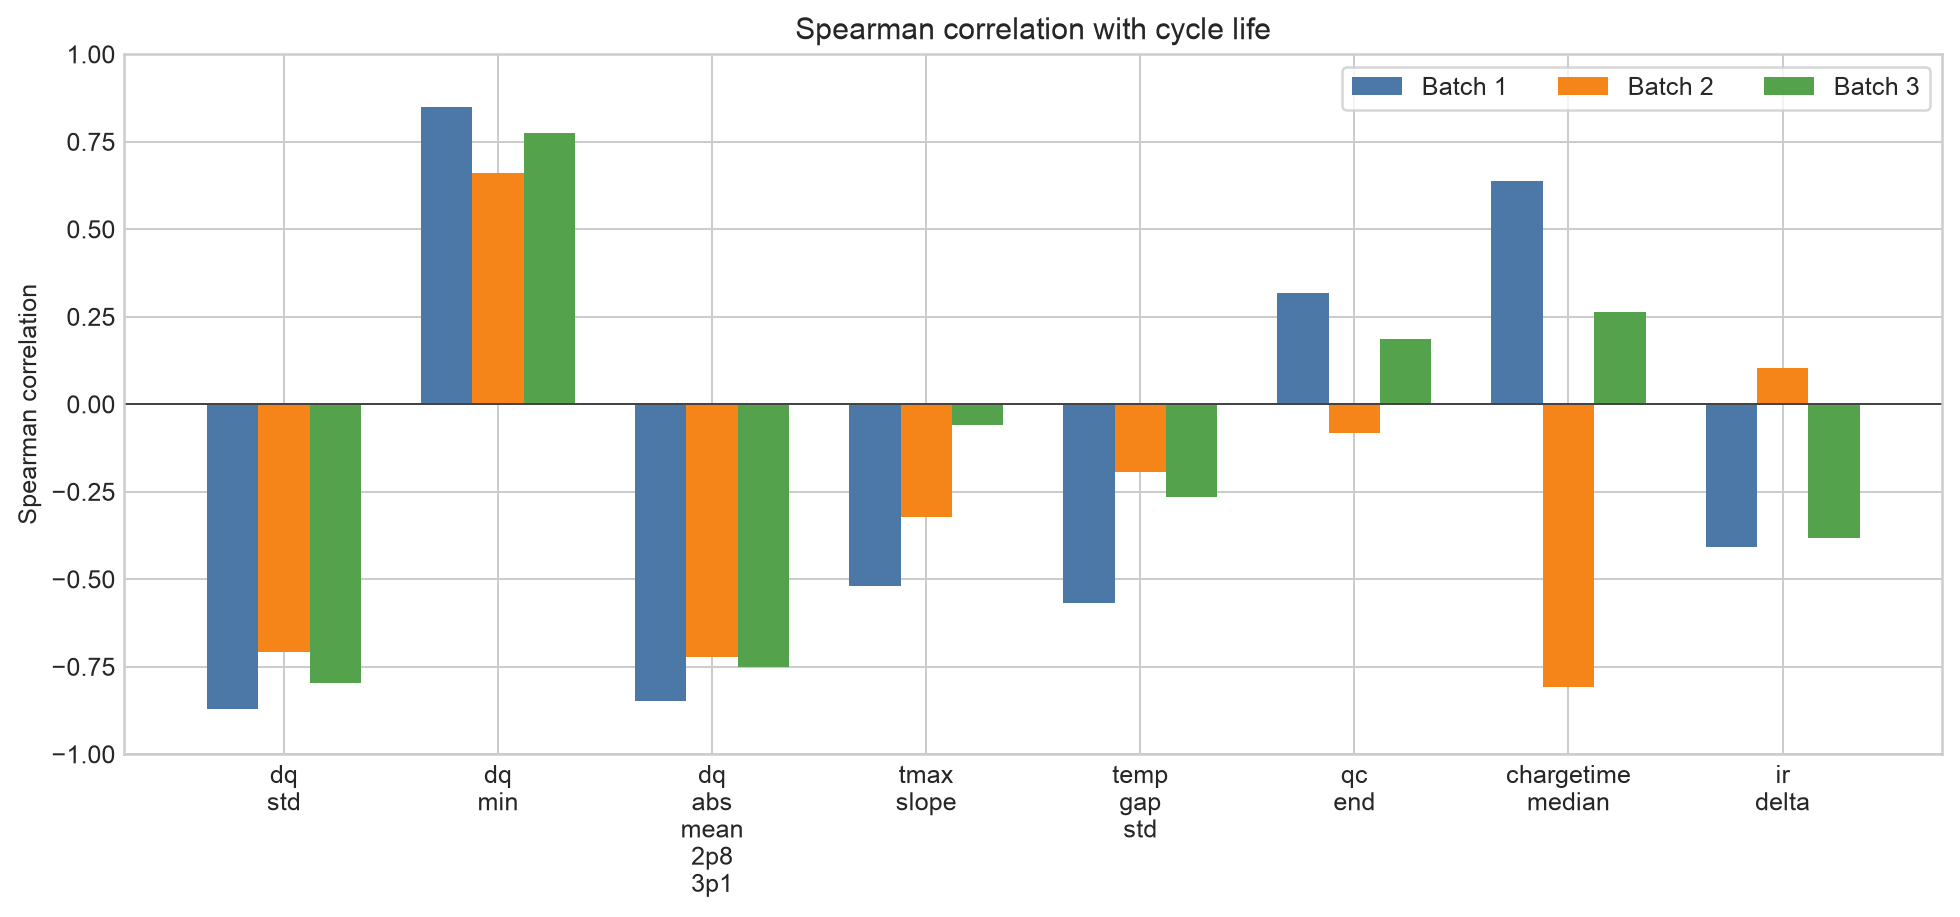

In [54]:
candidate_features = [
    'dq_std', 'dq_log_variance', 'dq_min', 'dq_abs_mean_2p8_3p1',
    'tmax_slope', 'temp_gap_std', 'qc_end', 'qd_end',
    'chargetime_median', 'ir_delta', 'policy_weighted_c', 'policy_soc',
]

corr_rows = []
for batch, group in labeled_df.groupby('batch'):
    for feature in candidate_features:
        valid = group[[feature, 'cycle_life']].dropna()
        corr_rows.append({
            'batch': batch, 'feature': feature,
            'spearman': spearmanr(valid[feature], valid['cycle_life']).statistic,
        })

cross_batch_corr = pd.DataFrame(corr_rows).pivot(
    index='feature', columns='batch', values='spearman'
)
cross_batch_corr['sign_consistent'] = (
    (np.sign(cross_batch_corr['Batch 1']) == np.sign(cross_batch_corr['Batch 2'])) &
    (np.sign(cross_batch_corr['Batch 2']) == np.sign(cross_batch_corr['Batch 3']))
)
cross_batch_corr['median_abs_corr'] = cross_batch_corr[
    ['Batch 1', 'Batch 2', 'Batch 3']
].abs().median(axis=1)
display(cross_batch_corr.sort_values('median_abs_corr', ascending=False).round(3))

plot_features = [
    'dq_std', 'dq_min', 'dq_abs_mean_2p8_3p1', 'tmax_slope',
    'temp_gap_std', 'qc_end', 'chargetime_median', 'ir_delta',
]
cross_batch_corr.loc[plot_features, ['Batch 1', 'Batch 2', 'Batch 3']].plot(
    kind='bar', figsize=(12, 5), ylim=(-1, 1)
)
plt.axhline(0, color='black', linewidth=.8)
plt.ylabel('Spearman correlation with cycle life')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


### 결과 2 — 배치 간 안정적인 피처

- `dq_std`와 `dq_log_variance`는 세 배치에서 각각 **-0.871, -0.709, -0.797**의 Spearman 상관을 보였다. 초기 10→100사이클 동안 ΔQ(V)의 변동이 클수록 수명이 짧아지는 관계가 모든 배치에서 유지된다.
- `dq_min`, `dq_abs_mean_2p8_3p1`도 강하지만 `dq_std`와의 Spearman 절댓값이 약 **0.995 이상**이므로 같은 정보를 중복해서 담는다. 이들을 동시에 투입하면 피처 수만 늘어난다.
- `chargetime_median`, `qc_end`, `ir_delta` 등은 배치마다 상관 방향이 바뀐다. Batch 1 안에서는 유용해 보여도 새로운 배치에서 일반화되지 않는다.
- 결론적으로 **현재 데이터에서 확정 추천할 핵심 피처는 `dq_std` 하나**이다. 해석 편의를 원하면 `dq_log_variance`로 대체할 수 있지만 둘을 동시에 사용하지 않는다.


feature_set,model,features,MAPE (%),MAE,R2
DQ only,ElasticNet,dq_std,24.37,123.8,0.559
DQ only,Ridge,dq_std,24.48,124.3,0.557
DQ only,RandomForest,dq_std,31.12,154.5,0.411
DQ only,GradientBoosting,dq_std,31.87,157.6,0.363
Compact 3,GradientBoosting,dq_std|qc_end|temp_gap_resid_std,34.83,177.6,0.246
Compact 2,GradientBoosting,dq_std|qc_end,37.08,188.5,0.169
Robust cross-batch,GradientBoosting,dq_std|qc_end|tmax_slope,37.22,188.5,0.171
Policy-aware,RandomForest,dq_std|qc_end|temp_gap_resid_std|policy_weighted_c,38.06,185.4,0.220
Compact 2,ElasticNet,dq_std|qc_end,38.10,191.3,0.035
Compact 2,Ridge,dq_std|qc_end,38.49,192.8,0.019


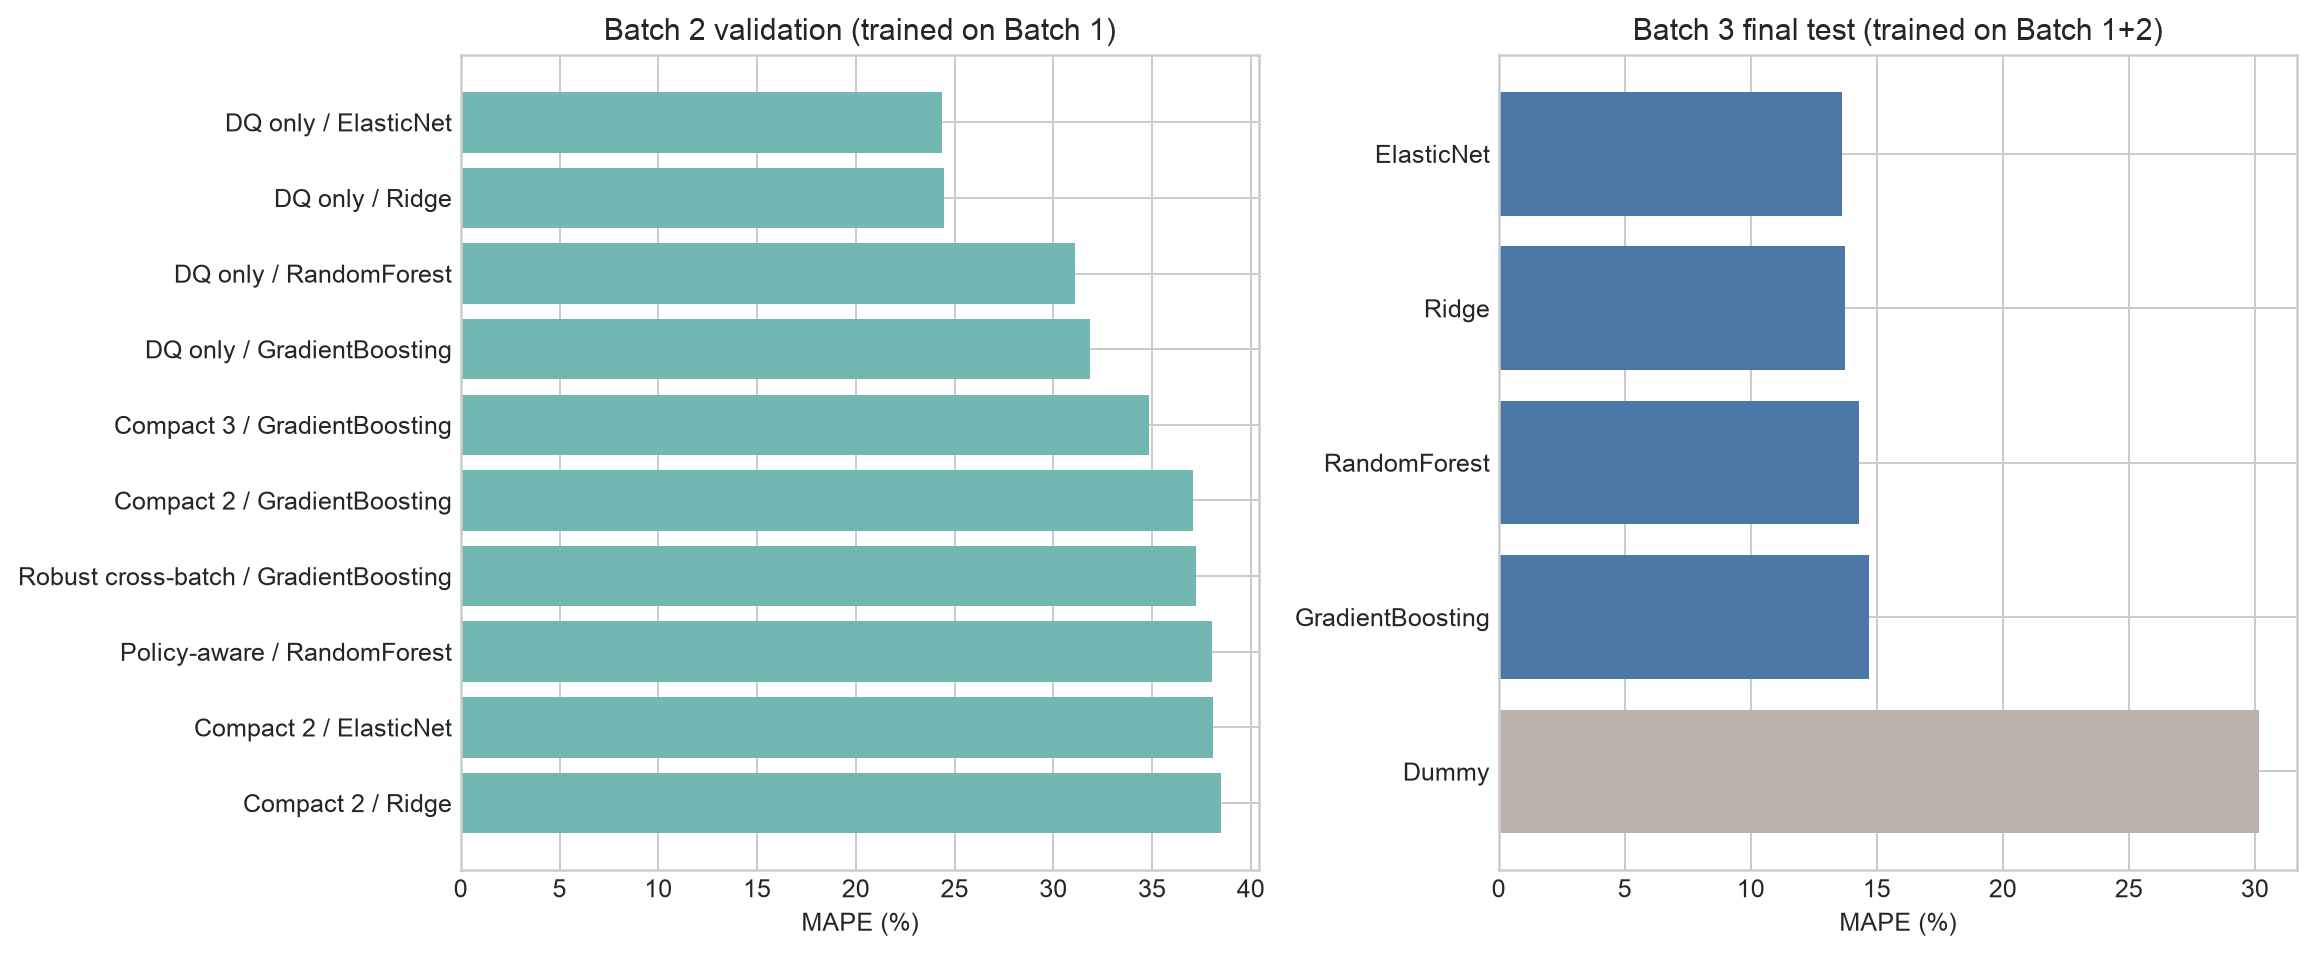

In [55]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.metrics import (
    mean_absolute_error, mean_absolute_percentage_error,
    mean_squared_error, r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def make_model(name):
    if name == 'Dummy':
        reg = Pipeline([('impute', SimpleImputer(strategy='median')),
                        ('model', DummyRegressor(strategy='median'))])
    elif name == 'Ridge':
        reg = Pipeline([('impute', SimpleImputer(strategy='median')),
                        ('scale', StandardScaler()),
                        ('model', RidgeCV(alphas=np.logspace(-4, 4, 41)))])
    elif name == 'ElasticNet':
        reg = Pipeline([('impute', SimpleImputer(strategy='median')),
                        ('scale', StandardScaler()),
                        ('model', ElasticNetCV(
                            l1_ratio=[.1, .3, .5, .7, .9],
                            alphas=np.logspace(-4, 0, 50), cv=5, max_iter=30000
                        ))])
    elif name == 'RandomForest':
        reg = Pipeline([('impute', SimpleImputer(strategy='median')),
                        ('model', RandomForestRegressor(
                            n_estimators=500, max_depth=3, min_samples_leaf=3,
                            max_features=.8, random_state=42
                        ))])
    elif name == 'GradientBoosting':
        reg = Pipeline([('impute', SimpleImputer(strategy='median')),
                        ('model', GradientBoostingRegressor(
                            n_estimators=150, learning_rate=.03, max_depth=2,
                            min_samples_leaf=3, loss='huber', random_state=42
                        ))])
    return TransformedTargetRegressor(regressor=reg, func=np.log, inverse_func=np.exp)

def evaluate(train, test, features, model_name):
    model = make_model(model_name)
    model.fit(train[features], train['cycle_life'])
    prediction = model.predict(test[features])
    return model, prediction, {
        'MAPE': mean_absolute_percentage_error(test['cycle_life'], prediction),
        'MAE': mean_absolute_error(test['cycle_life'], prediction),
        'RMSE': mean_squared_error(test['cycle_life'], prediction) ** .5,
        'R2': r2_score(test['cycle_life'], prediction),
    }

feature_sets = {
    'DQ only': ['dq_std'],
    'Compact 2': ['dq_std', 'qc_end'],
    'Compact 3': ['dq_std', 'qc_end', 'temp_gap_resid_std'],
    'Robust candidate': ['dq_std', 'qc_end', 'tmax_slope'],
    'Policy-aware': ['dq_std', 'qc_end', 'temp_gap_resid_std', 'policy_weighted_c'],
    'Mean summary': ['qd_mean', 'qd_std', 'ir_mean', 'tavg_mean', 'tmax_mean', 'chargetime_mean'],
}

batch1 = labeled_df[labeled_df['batch'] == 'Batch 1']
batch2 = labeled_df[labeled_df['batch'] == 'Batch 2']
batch3 = labeled_df[labeled_df['batch'] == 'Batch 3']

# Batch 1로 학습하고 Batch 2에서 피처 세트와 모델을 함께 선택한다.
rows = []
for set_name, features in feature_sets.items():
    for model_name in ['Ridge', 'ElasticNet', 'RandomForest', 'GradientBoosting']:
        _, _, score = evaluate(batch1, batch2, features, model_name)
        rows.append({'feature_set': set_name, 'model': model_name,
                     'features': '|'.join(features), **score})
validation_result = pd.DataFrame(rows).sort_values('MAPE')
display(validation_result.head(10).assign(
    MAPE=lambda x: (x['MAPE'] * 100).round(2),
    MAE=lambda x: x['MAE'].round(1), R2=lambda x: x['R2'].round(3)
))


### 결과 3 — 피처·모델 선택

- Batch 1 내부 교차검증에서는 `dq_std + qc_end` 등이 더 좋아 보일 수 있었지만, **Batch 1→Batch 2 외부 검증에서는 `dq_std` 단독이 가장 안정적**이었다.
- Batch 2 검증 MAPE는 `dq_std` 단독 ElasticNet **24.37%**, Ridge **24.48%**였다. `qc_end`와 온도·정책 피처를 더한 조합은 MAPE가 약 **38~54%**로 악화됐다.
- 이는 변수가 많을수록 좋아지는 것이 아니라, **배치 고유 패턴에 과적합될 수 있음**을 보여준다. 따라서 Batch 2에서 선택한 최종 조합은 `dq_std` + ElasticNet이다.


model,feature_set,features,MAPE (%),MAE,RMSE,R2
ElasticNet,DQ only,dq_std,13.60,173.2,273.9,0.221
Ridge,DQ only,dq_std,13.73,175.1,276.3,0.207
RandomForest,DQ only,dq_std,14.30,175.0,268.1,0.253
GradientBoosting,DQ only,dq_std,14.71,181.4,279.4,0.189
Dummy,DQ only,dq_std,30.16,364.8,472.0,-1.314


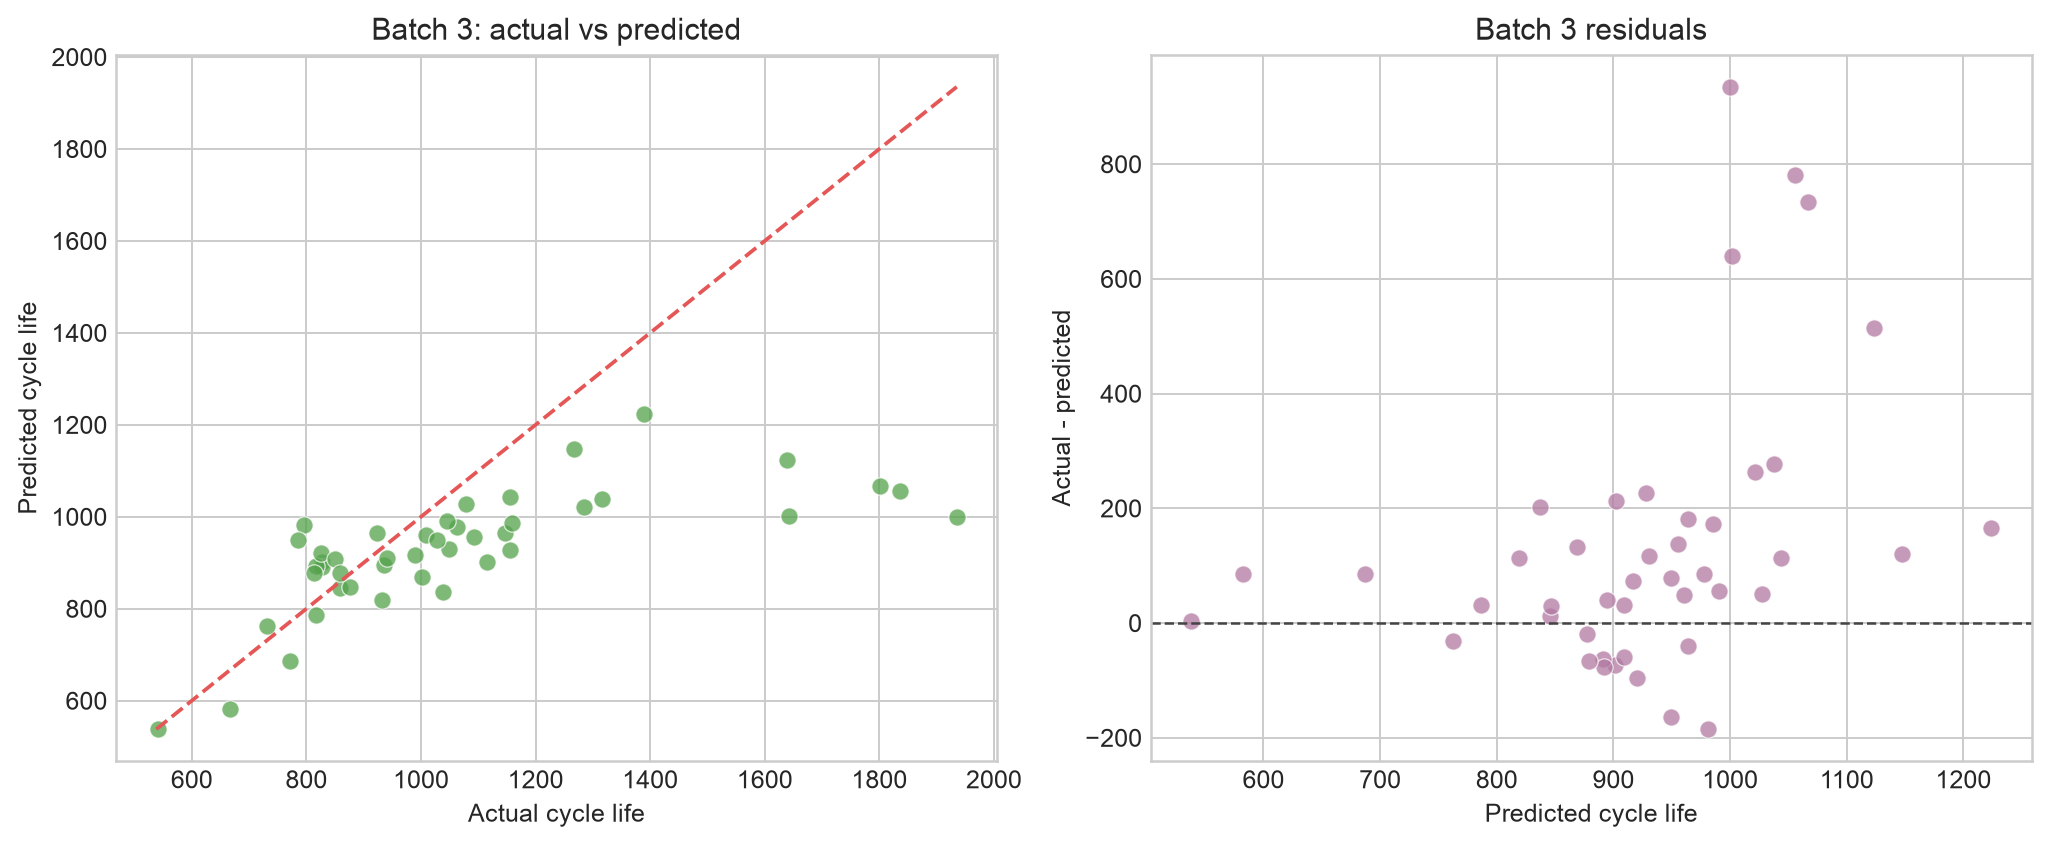

,cells,MAE,bias_actual_minus_pred,MAPE (%)
life_quartile,,,,
"(540.999, 828.0]",12,79.7,-45.7,10.15
"(828.0, 1005.5]",10,55.0,31.3,5.87
"(1005.5, 1155.25]",11,127.1,127.1,11.68
"(1155.25, 1935.0]",11,428.6,428.6,26.32


In [56]:
# Batch 2에서 선택을 끝낸 뒤 Batch 1+2로 재학습하고 Batch 3을 한 번만 최종 평가한다.
train12 = pd.concat([batch1, batch2], ignore_index=True)
test_rows = []
test_predictions = {}
for model_name in ['Dummy', 'Ridge', 'ElasticNet', 'RandomForest', 'GradientBoosting']:
    _, prediction, score = evaluate(train12, batch3, ['dq_std'], model_name)
    test_rows.append({'model': model_name, 'feature_set': 'DQ only',
                      'features': 'dq_std', **score})
    test_predictions[model_name] = prediction

batch3_test = pd.DataFrame(test_rows).sort_values('MAPE')
display(batch3_test.assign(
    MAPE=lambda x: (x['MAPE'] * 100).round(2),
    MAE=lambda x: x['MAE'].round(1), RMSE=lambda x: x['RMSE'].round(1),
    R2=lambda x: x['R2'].round(3)
))

final_prediction = test_predictions['ElasticNet']
residual = batch3['cycle_life'].to_numpy() - final_prediction
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
lo = min(batch3['cycle_life'].min(), final_prediction.min())
hi = max(batch3['cycle_life'].max(), final_prediction.max())
axes[0].scatter(batch3['cycle_life'], final_prediction, alpha=.75)
axes[0].plot([lo, hi], [lo, hi], '--', color='tomato')
axes[0].set(title='Batch 3: actual vs predicted', xlabel='Actual', ylabel='Predicted')
axes[1].scatter(final_prediction, residual, alpha=.75)
axes[1].axhline(0, linestyle='--', color='black')
axes[1].set(title='Batch 3 residuals', xlabel='Predicted', ylabel='Actual - predicted')
plt.tight_layout()
plt.show()

residual_check = pd.DataFrame({
    'cycle_life': batch3['cycle_life'].to_numpy(),
    'prediction': final_prediction,
    'residual': residual,
})
residual_check['life_quartile'] = pd.qcut(residual_check['cycle_life'], 4)
display(residual_check.groupby('life_quartile', observed=True).agg(
    cells=('residual', 'size'),
    MAE=('residual', lambda s: s.abs().mean()),
    bias_actual_minus_pred=('residual', 'mean'),
).round(1))


### 최종 인사이트

1. **가장 재현성 높은 조기 열화 신호는 ΔQ(V)의 변동성이다.** `dq_std`는 세 배치에서 수명과 강한 음의 단조 관계를 유지했다.
2. **배치 이동이 크다.** Batch별 수명 분포와 일부 피처-수명 관계가 다르므로 무작위 분할 점수만으로 모델을 선택하면 안 된다.
3. **단순한 모델이 더 안전하다.** Batch 2에서 미리 선택한 `dq_std` 단독 ElasticNet은 Batch 3에서 MAPE **13.60%**, MAE **173.2사이클**, R² **0.221**이었다. 중앙값만 예측한 Dummy의 MAPE **30.16%**보다 개선됐다.
4. **장수명 셀에서 과소예측이 크다.** Batch 3 최상위 수명 사분위의 MAPE는 약 **26.3%**, 평균 잔차(실제-예측)는 **+428.6사이클**이다. 전체 MAPE 하나만 제시하지 말고 수명 구간별 오차와 잔차를 함께 보고해야 한다.

### 최종 추천 피처

|구분|피처|사용 판단|근거|
|---|---|---|---|
|핵심|`dq_std = std(Q100(V)-Q10(V))`|**최종 사용**|세 배치에서 강하고 동일한 방향의 상관, 외부 배치 검증 1위|
|대체 표현|`dq_log_variance`|`dq_std` 대신 선택 가능|해석·스케일 안정성은 좋지만 `dq_std`와 완전히 중복|
|대체 ΔQ 요약|`dq_min`, `dq_abs_mean_2p8_3p1`|비교 실험용|강한 상관이나 `dq_std`와 약 0.995 이상 중복|
|보류|`qc_end`, `tmax_slope`, `temp_gap_resid_std`|현재 최종 모델에서는 제외|Batch 1 내부에서는 개선됐지만 Batch 2 외부 검증에서 성능 악화|
|보류|`policy_c1`, `policy_c2`, `policy_soc`, `policy_weighted_c`|설명·층화 분석용|배치별 정책 구성이 달라 모델이 배치/실험조건을 외울 위험|

### 추가 추천 파생변수

다음 변수는 **후속 실험 후보**이며 현재 결과만으로 확정 피처는 아니다.

- `dq_relative = (Q100(V)-Q10(V)) / (|Q10(V)|+ε)`의 표준편차·최솟값: 셀/배치 간 절대 용량 스케일 차이를 줄이는 정규화 ΔQ.
- 전압 구간별 ΔQ 면적(`2.0~2.6V`, `2.8~3.1V`, `3.1~3.2V`): 전체 변동이 어느 전압 구간에서 발생했는지 분리한다. 단, 구간 피처끼리 중복성이 높으므로 규제 또는 하나의 구간만 선택한다.
- `IR_slope`, `temperature_rise_slope`, `charge_time_slope`: 평균값보다 초기 10~100사이클의 변화율을 사용한다. 반드시 배치 외부 검증을 통과한 경우에만 채택한다.
- `temperature_per_C = (Tmax-Tavg)/policy_weighted_c`: 충전 강도 대비 발열을 표현한다. 정책 정보가 없는 운영 환경에서는 사용하지 않는다.

### 모델 설계 전략

1. **문제 정의:** Regression, Target=`cycle_life`; 입력은 최초 100사이클까지만 사용한다.
2. **분할:** Batch 1=탐색/학습, Batch 2=피처·하이퍼파라미터 선택, Batch 3=최종 테스트. 같은 셀의 사이클이 서로 다른 세트에 들어가지 않게 한다.
3. **전처리:** 결측 Target은 제거하고 피처 결측은 학습 세트 중앙값으로 대체한다. 선형모델은 표준화하며, 우측 꼬리가 있는 Target에는 `log(cycle_life)`를 적용한다.
4. **최종 후보:** 해석성과 안정성이 높은 ElasticNet/Ridge를 1순위로 사용하고, RandomForest/GradientBoosting은 비선형 비교 모델로만 둔다.
5. **평가:** MAPE·MAE·RMSE·R²와 함께 수명 사분위별 MAE/편향, 실제-예측 및 잔차 그래프를 보고한다.
6. **주의:** Batch 3 결과를 확인한 뒤 다시 피처를 바꾸면 최종 테스트가 검증 세트가 된다. 추가 개선이 필요하면 새로운 배치 또는 nested/group CV를 확보한다.


<!-- CODEX_DAY2_START -->
# 7. DAY2 — 모델 개발 및 평가

### 과제 기준

- **Task:** 초기 100사이클로 `cycle_life`를 예측하는 Regression
- **Train:** Batch 1
- **Valid:** Batch 1 내부의 충전 프로토콜 단위 Hold-out
- **Test:** Batch 2(필수), Batch 3(추가 검증)
- **Primary metric:** MAPE
- **논문 Target:** 9.1% MAPE

> 앞의 6장은 배치 이동과 피처 안정성을 확인하기 위한 탐색적 EDA이다. DAY2의 피처·모델 선택은 Batch 2·3의 Target을 보지 않고 Batch 1 안에서 다시 수행한다.


## 7.1 데이터 정제와 누수 방지 분할

공식 데이터 로딩 코드의 제외 기준을 반영한다. Batch 1에서는 실험이 끝까지 완료되지 않은 5개 셀을 제외하고, Batch 3에서는 데이터 수집 실패·미완주·노이즈 셀 6개를 제외한다. Batch 2는 `cycle_life`가 비어 있는 셀만 제외한다.

동일한 충전 정책 셀이 개발·검증 세트에 동시에 들어가지 않도록 **정책 단위로 분할**한다. Hold-out 정책은 수명 사분위가 유지되도록 층화한다.


In [61]:
from sklearn.model_selection import GroupKFold, cross_validate, train_test_split

# 공식 LoadData.m 기준의 미완주·이상 셀 제외
batch1_day2 = batch123_df[
    (batch123_df['batch'] == 'Batch 1') &
    batch123_df['cycle_life'].notna() &
    ~batch123_df['cell_id'].isin([8, 10, 12, 13, 22])
].copy()
batch2_day2 = batch123_df[
    (batch123_df['batch'] == 'Batch 2') & batch123_df['cycle_life'].notna()
].copy()
batch3_day2 = batch123_df[
    (batch123_df['batch'] == 'Batch 3') &
    batch123_df['cycle_life'].notna() &
    ~batch123_df['cell_id'].isin([2, 23, 32, 37, 42, 43])
].copy()

# 충전 정책 평균 수명을 사분위로 나눈 뒤 정책 자체를 Hold-out한다.
policy_table = batch1_day2.groupby('policy', as_index=False)['cycle_life'].mean()
policy_table['life_bin'] = pd.qcut(
    policy_table['cycle_life'], 4, labels=False, duplicates='drop'
)
dev_policy, valid_policy = train_test_split(
    policy_table['policy'], test_size=.25, random_state=42,
    stratify=policy_table['life_bin']
)
batch1_dev = batch1_day2[batch1_day2['policy'].isin(dev_policy)].copy()
batch1_valid = batch1_day2[batch1_day2['policy'].isin(valid_policy)].copy()
assert set(batch1_dev['policy']).isdisjoint(set(batch1_valid['policy']))

split_summary = pd.DataFrame({
    'dataset': ['Batch 1 development', 'Batch 1 hold-out', 'Batch 2 test', 'Batch 3 test'],
    'cells': [len(batch1_dev), len(batch1_valid), len(batch2_day2), len(batch3_day2)],
    'charging_policies': [batch1_dev.policy.nunique(), batch1_valid.policy.nunique(),
                          batch2_day2.policy.nunique(), batch3_day2.policy.nunique()],
    'role': ['model/parameter selection', 'internal validation',
             'mandatory final test', 'additional final test'],
})
display(split_summary)


import matplotlib.pyplot as plt

DAY2_RESULT_DIR = PROJECT_DIR / 'results'
DAY2_FIGURE_DIR = DAY2_RESULT_DIR / 'figures'
DAY2_RESULT_DIR.mkdir(exist_ok=True)
DAY2_FIGURE_DIR.mkdir(exist_ok=True)


dataset,cells,charging_policies,role
Batch 1 development,31,16.0,model/parameter selection
Batch 1 hold-out,10,6.0,internal validation
Batch 2 test,39,NaN,mandatory final test
Batch 3 test,40,NaN,additional final test


## 7.2 후보 피처·모델과 선택 원칙

EDA와 직접 연결되는 피처 세트를 비교한다.

- `DQ only`: 세 배치에서 가장 안정적이었던 `dq_std`
- `DQ + charge`: Batch 1 내부 성능을 개선했던 `qc_end` 추가
- `DQ shape`: ΔQ의 표준편차·최솟값·2.8~3.1V 변화량
- `DQ + thermal`: 초기 온도 상승 추세 추가
- `DQ + policy`: 충전 C-rate 파생변수 추가
- `Summary baseline`: 기존 평균 요약 피처

후보 모델은 Ridge, ElasticNet, RandomForest, GradientBoosting이며 Dummy를 기준선으로 둔다. Target은 우측 꼬리를 줄이기 위해 `log(cycle_life)`로 학습한다.


In [62]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

feature_sets_day2 = {
    'DQ only': ['dq_std'],
    'DQ shape': ['dq_std', 'dq_min', 'dq_abs_mean_2p8_3p1'],
    'DQ + charge': ['dq_std', 'qc_end'],
    'DQ + thermal': ['dq_std', 'tmax_slope', 'temp_gap_std'],
    'DQ + policy': ['dq_std', 'policy_weighted_c', 'policy_soc', 'policy_gap'],
    'Compact all': ['dq_std', 'qc_end', 'tmax_slope', 'temp_gap_std',
                    'policy_weighted_c', 'policy_soc'],
    'Summary baseline': ['qd_mean', 'qd_std', 'ir_mean', 'tavg_mean',
                         'tmax_mean', 'chargetime_mean'],
}

def make_day2_estimator(model_name, params):
    steps = [('impute', SimpleImputer(strategy='median'))]
    if model_name in {'Ridge', 'ElasticNet'}:
        steps.append(('scale', StandardScaler()))
    if model_name == 'Dummy':
        model = DummyRegressor(strategy='median')
    elif model_name == 'Ridge':
        model = Ridge(alpha=params['alpha'])
    elif model_name == 'ElasticNet':
        model = ElasticNet(alpha=params['alpha'], l1_ratio=params['l1_ratio'], max_iter=30000)
    elif model_name == 'RandomForest':
        model = RandomForestRegressor(
            n_estimators=400, max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            max_features=params['max_features'], random_state=42, n_jobs=-1
        )
    elif model_name == 'GradientBoosting':
        model = GradientBoostingRegressor(
            n_estimators=params['n_estimators'], learning_rate=params['learning_rate'],
            max_depth=params['max_depth'], min_samples_leaf=params['min_samples_leaf'],
            loss='huber', random_state=42
        )
    steps.append(('model', model))
    return TransformedTargetRegressor(
        regressor=Pipeline(steps), func=np.log, inverse_func=np.exp
    )

def day2_candidates():
    yield 'Dummy', {}
    for alpha in [.01, .1, 1, 10, 100]:
        yield 'Ridge', {'alpha': alpha}
    for alpha in [.001, .01, .1]:
        for l1_ratio in [.1, .5, .9]:
            yield 'ElasticNet', {'alpha': alpha, 'l1_ratio': l1_ratio}
    for depth, leaf, max_features in [(2, 2, 1.0), (3, 3, .8), (None, 4, .8)]:
        yield 'RandomForest', {
            'max_depth': depth, 'min_samples_leaf': leaf, 'max_features': max_features
        }
    for n, rate, depth, leaf in [(100, .03, 1, 3), (150, .03, 2, 3), (100, .05, 2, 4)]:
        yield 'GradientBoosting', {
            'n_estimators': n, 'learning_rate': rate,
            'max_depth': depth, 'min_samples_leaf': leaf
        }


feature_set,model,features,CV MAPE (%),CV std (%p)
DQ + charge,ElasticNet,dq_std|qc_end,7.12,1.77
Compact all,ElasticNet,dq_std|qc_end|tmax_slope|temp_gap_std|policy_weighted_c|policy_soc,8.17,2.56
DQ shape,Ridge,dq_std|dq_min|dq_abs_mean_2p8_3p1,8.61,1.84
DQ only,Ridge,dq_std,8.84,1.06
DQ + policy,ElasticNet,dq_std|policy_weighted_c|policy_soc|policy_gap,9.73,1.59
DQ + thermal,ElasticNet,dq_std|tmax_slope|temp_gap_std,10.47,4.81
Summary baseline,GradientBoosting,qd_mean|qd_std|ir_mean|tavg_mean|tmax_mean|chargetime_mean,16.46,5.78


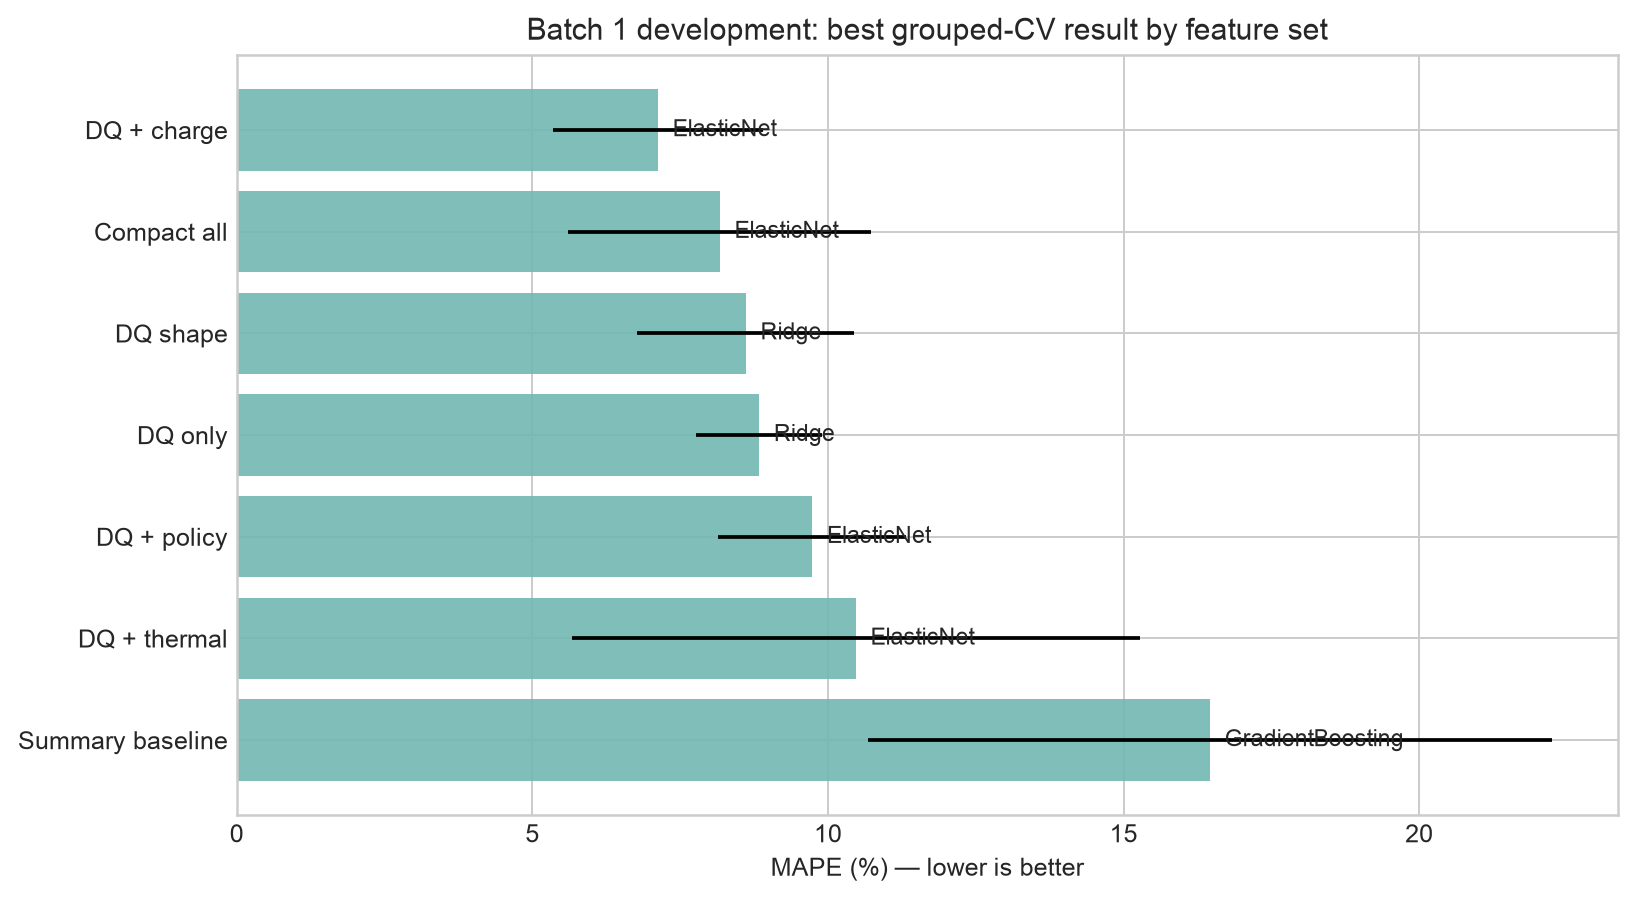

In [63]:
# Batch 1 development set에서 충전 정책을 그룹으로 묶은 5-fold CV
import json

cv = GroupKFold(n_splits=5)
search_rows = []
for feature_set, features in feature_sets_day2.items():
    for model_name, params in day2_candidates():
        estimator = make_day2_estimator(model_name, params)
        score = cross_validate(
            estimator, batch1_dev[features], batch1_dev['cycle_life'],
            groups=batch1_dev['policy'], cv=cv,
            scoring={'mape': 'neg_mean_absolute_percentage_error',
                     'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
            n_jobs=-1
        )
        search_rows.append({
            'feature_set': feature_set, 'features': '|'.join(features),
            'model': model_name, 'params': json.dumps(params, sort_keys=True),
            'cv_mape_mean': -score['test_mape'].mean(),
            'cv_mape_std': score['test_mape'].std(),
            'cv_mae_mean': -score['test_mae'].mean(),
            'cv_r2_mean': score['test_r2'].mean(),
        })
cv_search = pd.DataFrame(search_rows).sort_values(['cv_mape_mean', 'cv_mape_std'])

# 최저 오차를 무조건 선택하지 않고 one-standard-error 규칙으로 단순한 모델 선택
raw_cv_winner = cv_search.iloc[0]
one_se_limit = raw_cv_winner.cv_mape_mean + raw_cv_winner.cv_mape_std
eligible = cv_search[cv_search.cv_mape_mean <= one_se_limit].copy()
eligible['feature_count'] = eligible.features.str.count(r'\|') + 1
eligible['model_complexity'] = eligible.model.map({
    'Dummy': 0, 'Ridge': 1, 'ElasticNet': 2,
    'GradientBoosting': 3, 'RandomForest': 4
})
selected = eligible.sort_values(
    ['feature_count', 'model_complexity', 'cv_mape_std', 'cv_mape_mean']
).iloc[0]

best_by_set = cv_search.groupby('feature_set', as_index=False).first()
display(best_by_set.sort_values('cv_mape_mean')[
    ['feature_set', 'model', 'features', 'cv_mape_mean', 'cv_mape_std']
].round(4))
print('Raw CV winner :', raw_cv_winner.feature_set, '/', raw_cv_winner.model)
print('One-SE limit   :', round(one_se_limit, 4))
print('Final selected :', selected.feature_set, '/', selected.model,
      json.loads(selected.params))


# 피처 세트별 최고 Group-CV 성능 시각화
cv_plot = best_by_set.sort_values('cv_mape_mean')
fig, ax = plt.subplots(figsize=(9.2, 5.1))
bars = ax.barh(
    cv_plot['feature_set'], cv_plot['cv_mape_mean'] * 100,
    xerr=cv_plot['cv_mape_std'] * 100, color='#72B7B2', alpha=.9
)
ax.invert_yaxis()
ax.set(
    title='Batch 1 development: best grouped-CV result by feature set',
    xlabel='MAPE (%) — lower is better'
)
for bar, model_name in zip(bars, cv_plot['model']):
    ax.text(
        bar.get_width() + .25, bar.get_y() + bar.get_height() / 2,
        model_name, va='center', fontsize=9
    )
fig.tight_layout()
fig.savefig(
    DAY2_FIGURE_DIR / '01_cv_feature_model_comparison.png',
    dpi=180, bbox_inches='tight', facecolor='white'
)
plt.show()


### 선택 결과

최저 CV MAPE는 `dq_std + qc_end` ElasticNet의 **7.12%**였다. 그러나 표본이 31개뿐이고 `qc_end`는 배치별 상관 방향이 바뀌었던 피처다. 최저 오차에 CV 표준편차 1개를 더한 범위 안에서 가장 단순한 모델을 선택하는 **one-standard-error 규칙**을 적용했다.

최종 모델은 다음과 같다.

- Feature: `dq_std`
- Model: Ridge (`alpha=0.01`)
- Target transformation: `log(cycle_life)`

이는 내부 점수를 약간 양보하고 새 배치에 대한 과적합 위험을 줄이는 선택이다.


Index,MAPE (%),CV std (%p),note
Train (Batch 1 CV),8.84,1.06,5-fold GroupKFold by charging policy
Valid (Batch 1 Hold-out),7.09,NaN,policy-disjoint stratified 25% hold-out
Test (Batch 2),24.39,NaN,mandatory external batch test
Gap (Train-Valid),-1.75,NaN,(+) suggests overfitting
Gap (Valid-Test),17.31,NaN,(+) suggests batch generalization loss
Gap (Target-Test),15.29,NaN,paper target = 9.1%
Test (Batch 3),12.71,NaN,additional external batch test
Gap (Batch2-Batch3),-11.69,NaN,(+) means Batch 3 is worse
"Gap (Target-Test, Batch 3)",3.61,NaN,paper target = 9.1%


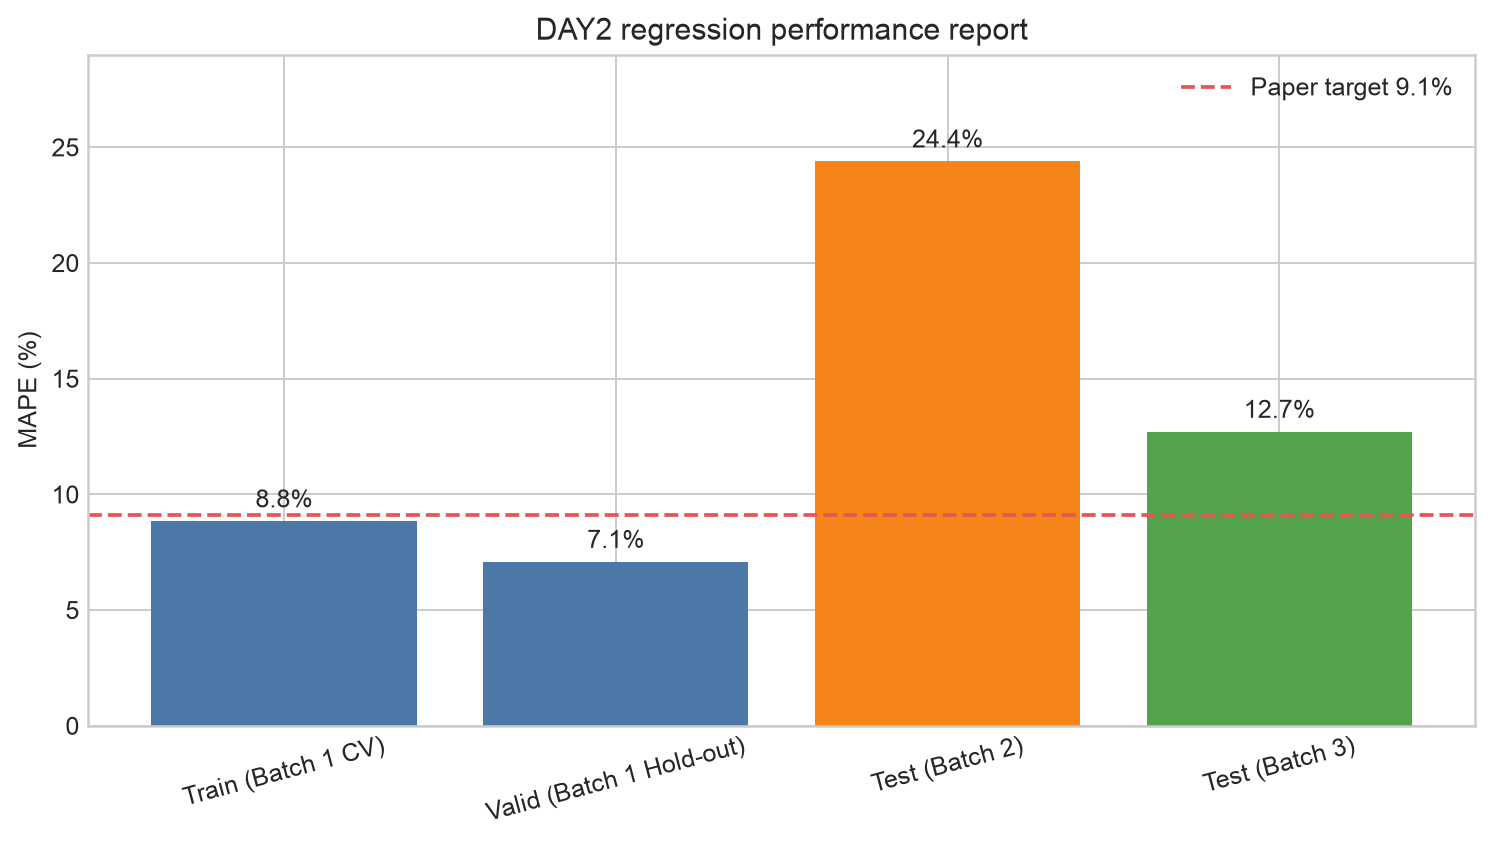

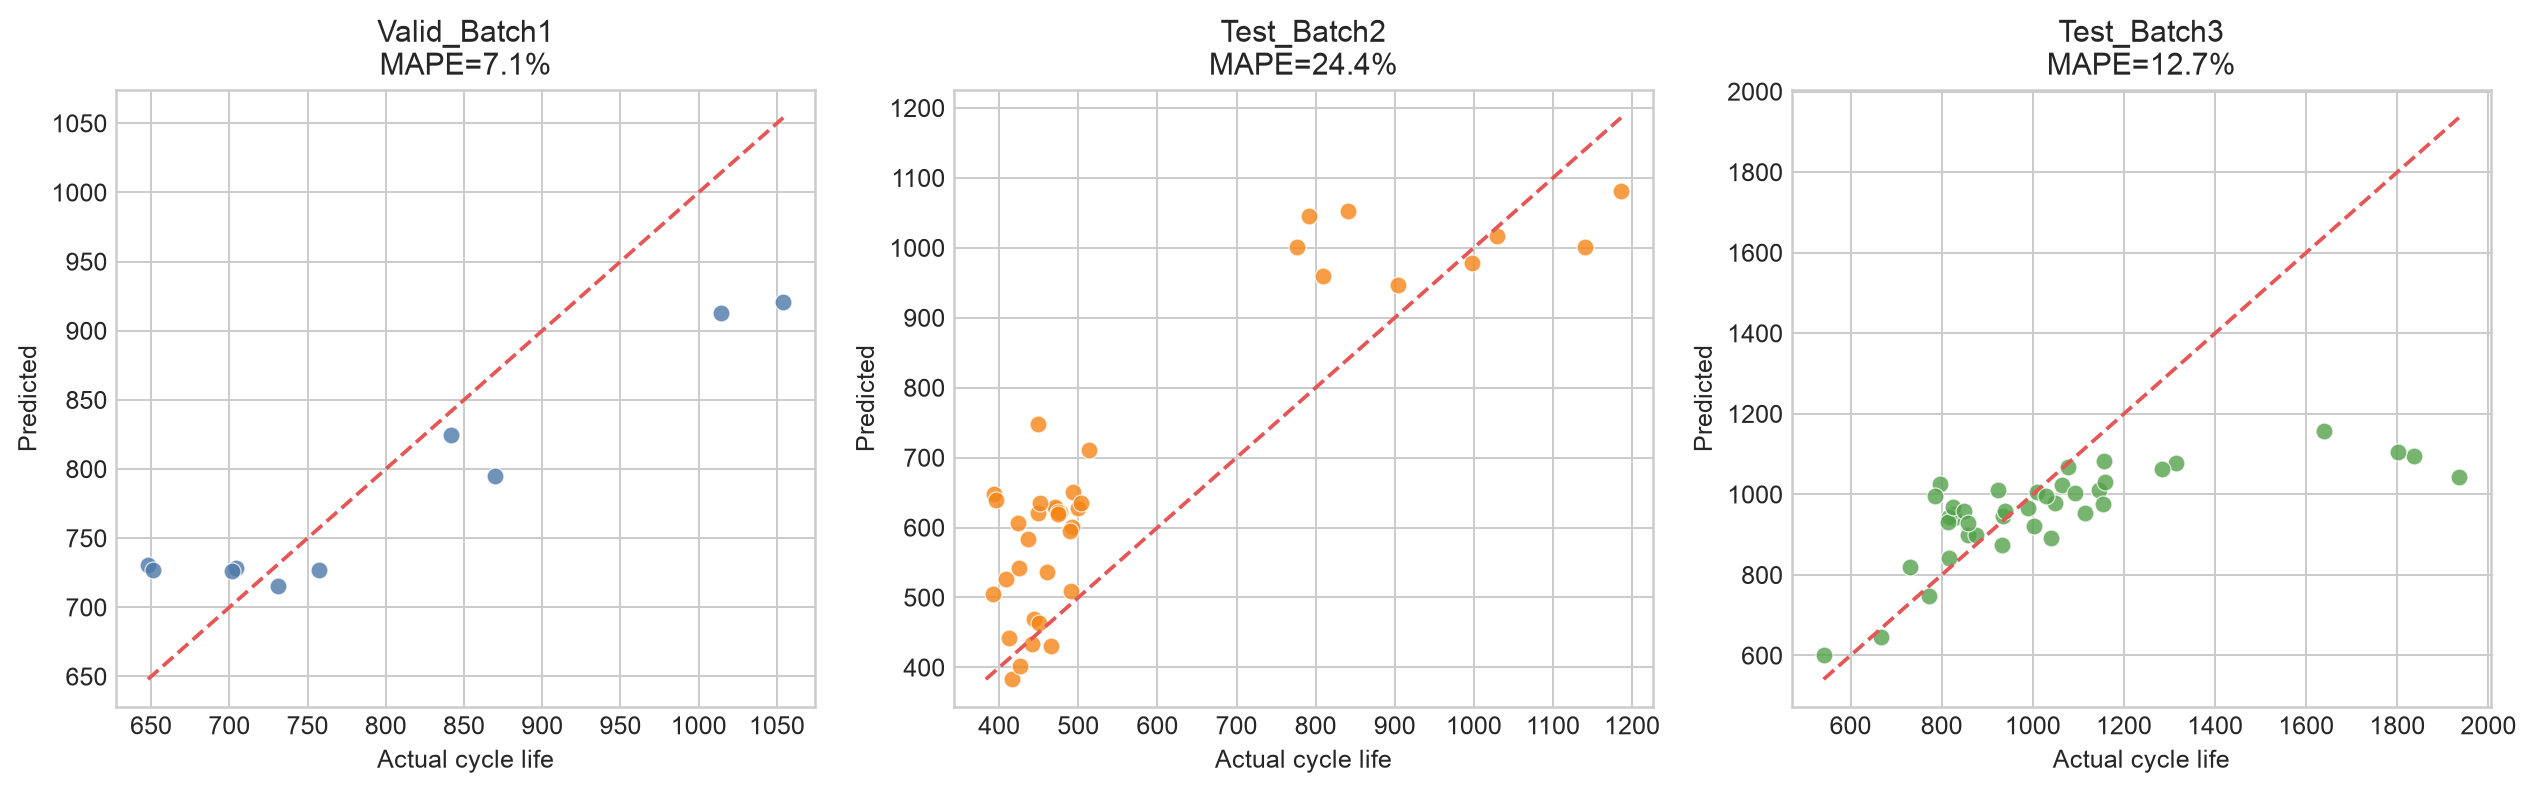

In [64]:
from sklearn.metrics import (
    mean_absolute_error, mean_absolute_percentage_error,
    mean_squared_error, r2_score
)

def regression_scores(actual, prediction):
    return {
        'MAPE': mean_absolute_percentage_error(actual, prediction),
        'MAE': mean_absolute_error(actual, prediction),
        'RMSE': mean_squared_error(actual, prediction) ** .5,
        'R2': r2_score(actual, prediction),
    }

selected_features = selected.features.split('|')
selected_params = json.loads(selected.params)

# Hold-out 평가는 개발 셀만으로 학습
holdout_model = make_day2_estimator(selected.model, selected_params)
holdout_model.fit(batch1_dev[selected_features], batch1_dev['cycle_life'])
valid_prediction = holdout_model.predict(batch1_valid[selected_features])
valid_score = regression_scores(batch1_valid['cycle_life'], valid_prediction)

# 선택 완료 후 Batch 1 전체로 재학습, Batch 2·3 Target은 평가에만 사용
final_model = make_day2_estimator(selected.model, selected_params)
final_model.fit(batch1_day2[selected_features], batch1_day2['cycle_life'])
batch2_prediction = final_model.predict(batch2_day2[selected_features])
batch3_prediction = final_model.predict(batch3_day2[selected_features])
batch2_score = regression_scores(batch2_day2['cycle_life'], batch2_prediction)
batch3_score = regression_scores(batch3_day2['cycle_life'], batch3_prediction)

paper_target = .091
performance_report = pd.DataFrame([
    ['Train (Batch 1 CV)', selected.cv_mape_mean, selected.cv_mape_std,
     '5-fold GroupKFold by charging policy'],
    ['Valid (Batch 1 Hold-out)', valid_score['MAPE'], np.nan,
     'policy-disjoint stratified 25% hold-out'],
    ['Test (Batch 2)', batch2_score['MAPE'], np.nan, 'mandatory external batch test'],
    ['Gap (Train-Valid)', valid_score['MAPE'] - selected.cv_mape_mean, np.nan,
     '(+) : overfitting suspected'],
    ['Gap (Valid-Test)', batch2_score['MAPE'] - valid_score['MAPE'], np.nan,
     '(+) : batch generalization loss'],
    ['Gap (Target-Test)', batch2_score['MAPE'] - paper_target, np.nan,
     'paper target = 9.1%'],
    ['Test (Batch 3)', batch3_score['MAPE'], np.nan, 'additional external batch test'],
    ['Gap (Batch2-Batch3)', batch3_score['MAPE'] - batch2_score['MAPE'], np.nan,
     '(+) means Batch 3 is worse'],
    ['Gap (Target-Test, Batch 3)', batch3_score['MAPE'] - paper_target, np.nan,
     'paper target = 9.1%'],
], columns=['Index', 'MAPE', 'MAPE_std', 'note'])

display(performance_report.assign(
    **{'MAPE (%)': (performance_report.MAPE * 100).round(2),
       'CV std (%p)': (performance_report.MAPE_std * 100).round(2)}
)[['Index', 'MAPE (%)', 'CV std (%p)', 'note']])


# 과제 형식의 MAPE 성능표 시각화
report_rows = performance_report[performance_report['Index'].isin([
    'Train (Batch 1 CV)', 'Valid (Batch 1 Hold-out)',
    'Test (Batch 2)', 'Test (Batch 3)'
])].copy()
fig, ax = plt.subplots(figsize=(8.4, 4.8))
report_colors = ['#4C78A8', '#4C78A8', '#F58518', '#54A24B']
bars = ax.bar(report_rows['Index'], report_rows['MAPE'] * 100, color=report_colors)
ax.axhline(
    paper_target * 100, linestyle='--', linewidth=1.5,
    color='#E45756', label='Paper target 9.1%'
)
for bar, value in zip(bars, report_rows['MAPE'] * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, value + .6,
            f'{value:.1f}%', ha='center')
ax.set(title='DAY2 regression performance report', ylabel='MAPE (%)', ylim=(0, 29))
ax.tick_params(axis='x', rotation=15)
ax.legend()
fig.tight_layout()
fig.savefig(
    DAY2_FIGURE_DIR / '02_performance_report.png',
    dpi=180, bbox_inches='tight', facecolor='white'
)
plt.show()

# Hold-out, Batch 2, Batch 3 실제값-예측값 비교
parity_data = [
    ('Valid_Batch1', batch1_valid, valid_prediction, '#4C78A8'),
    ('Test_Batch2', batch2_day2, batch2_prediction, '#F58518'),
    ('Test_Batch3', batch3_day2, batch3_prediction, '#54A24B'),
]
fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.5))
for ax, (split_name, frame, prediction, color) in zip(axes, parity_data):
    actual = frame['cycle_life'].to_numpy()
    lo, hi = min(actual.min(), prediction.min()), max(actual.max(), prediction.max())
    split_mape = mean_absolute_percentage_error(actual, prediction) * 100
    ax.scatter(actual, prediction, s=46, alpha=.8, color=color,
               edgecolor='white', linewidth=.5)
    ax.plot([lo, hi], [lo, hi], '--', color='#E45756')
    ax.set(title=f'{split_name}\nMAPE={split_mape:.1f}%',
           xlabel='Actual cycle life', ylabel='Predicted')
fig.tight_layout()
fig.savefig(
    DAY2_FIGURE_DIR / '03_actual_vs_predicted.png',
    dpi=180, bbox_inches='tight', facecolor='white'
)
plt.show()


## 7.3 Performance Reporting 해석

|구분|결과|해석|
|---|---:|---|
|Train (Batch 1 CV)|8.84%|논문 목표 9.1%와 유사|
|Valid (Batch 1 Hold-out)|7.09%|Train보다 1.75%p 낮아 내부 과적합 징후 없음|
|Test (Batch 2)|24.39%|Valid보다 17.31%p 악화, 배치 일반화 저하|
|Gap (Target-Test)|+15.29%p|논문 9.1%보다 큰 오차|
|Test (Batch 3)|12.71%|Batch 2보다 11.69%p 개선|
|Batch 3 Target Gap|+3.61%p|원논문과 비교적 가까운 수준|

Batch 1 내부에서는 목표 성능에 도달했지만 Batch 2에서 크게 악화됐다. 이는 단순한 학습 과적합보다는 **Batch 2의 Target·충전정책·`dq_std` 분포 이동**이 주요 원인임을 의미한다.


split,cell_id,policy,cycle_life,prediction,residual,APE (%)
Test_Batch2,18,5.2C(50%)-4.25C,449.0,748.7,-299.7,66.7
Test_Batch2,6,3.6C(9%)-5C,393.0,647.5,-254.5,64.8
Test_Batch2,15,3.6C(9%)-5C,396.0,639.4,-243.4,61.5
Test_Batch3,38,5C(67%)-4C-newstructure,1935.0,1043.9,891.1,46.1
Test_Batch2,2,5.2C(50%)-4.25C,424.0,606.3,-182.3,43.0
Test_Batch2,29,5.2C(58%)-4C,452.0,634.7,-182.7,40.4
Test_Batch3,7,4.8C(80%)-4.8C-newstructure,1836.0,1095.2,740.8,40.3
Test_Batch3,45,4.8C(80%)-4.8C-newstructure,1801.0,1105.6,695.4,38.6
Test_Batch3,16,4.8C(80%)-4.8C-newstructure,1638.0,1157.1,480.9,29.4
Test_Batch3,40,5.6C(19%)-4.6C-newstructure,796.0,1026.2,-230.2,28.9


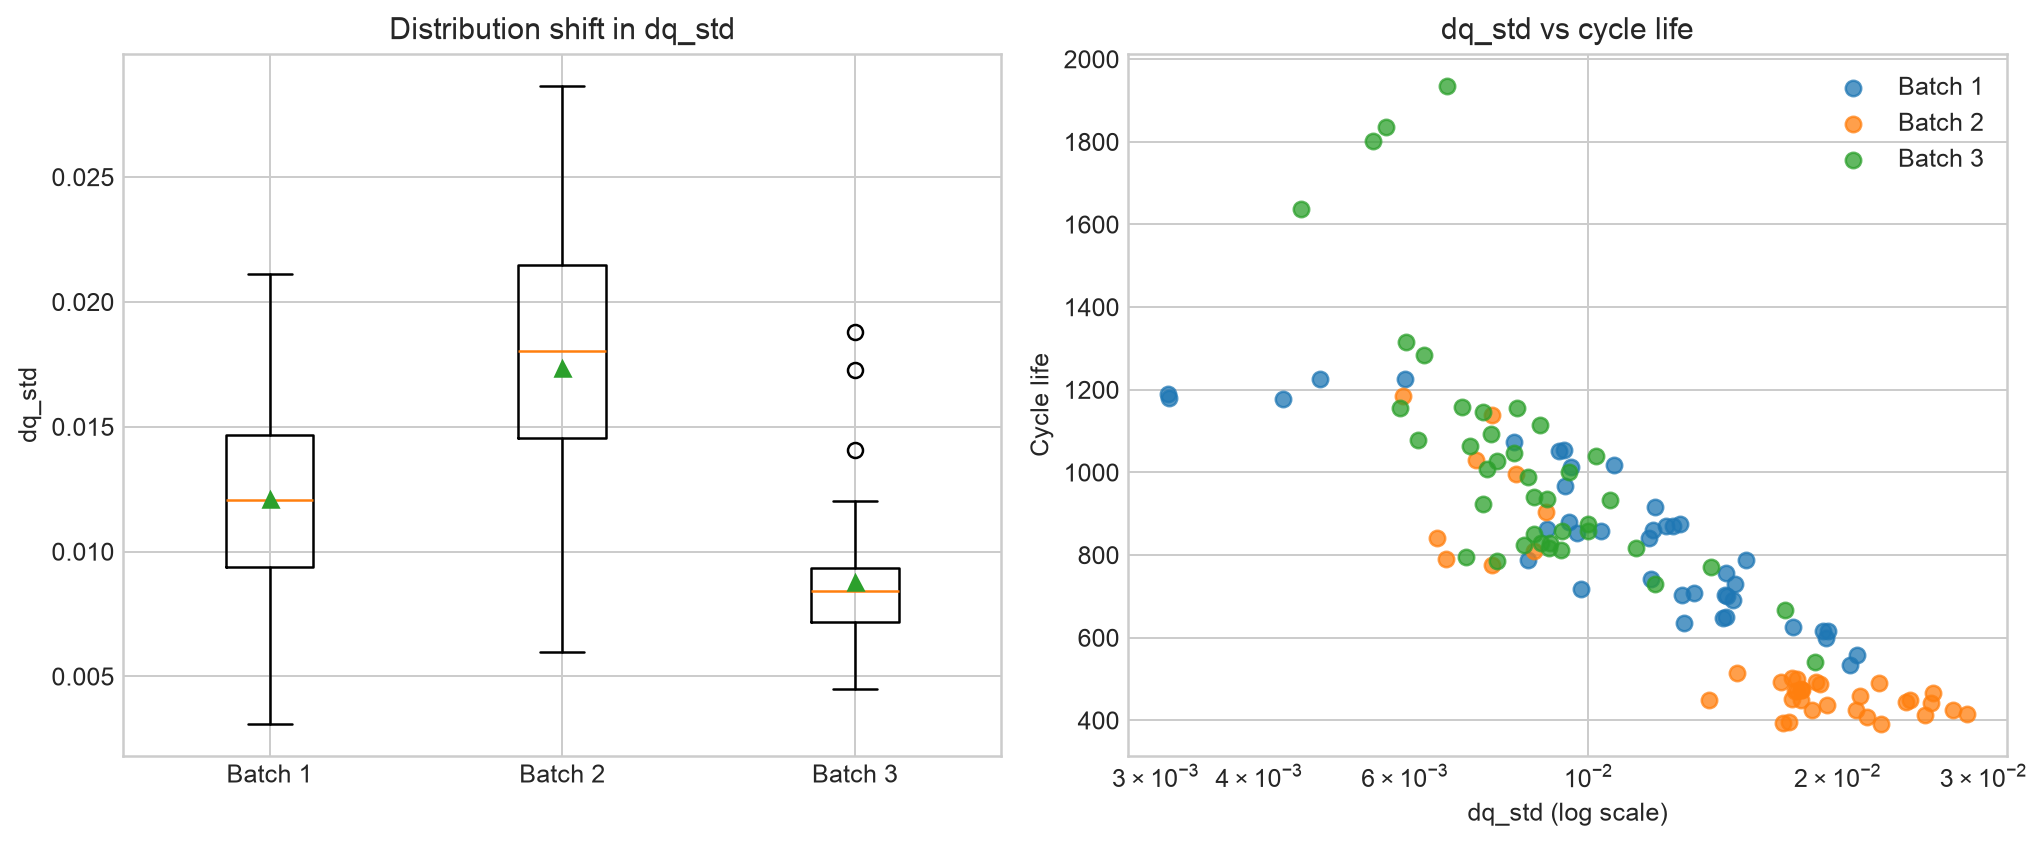

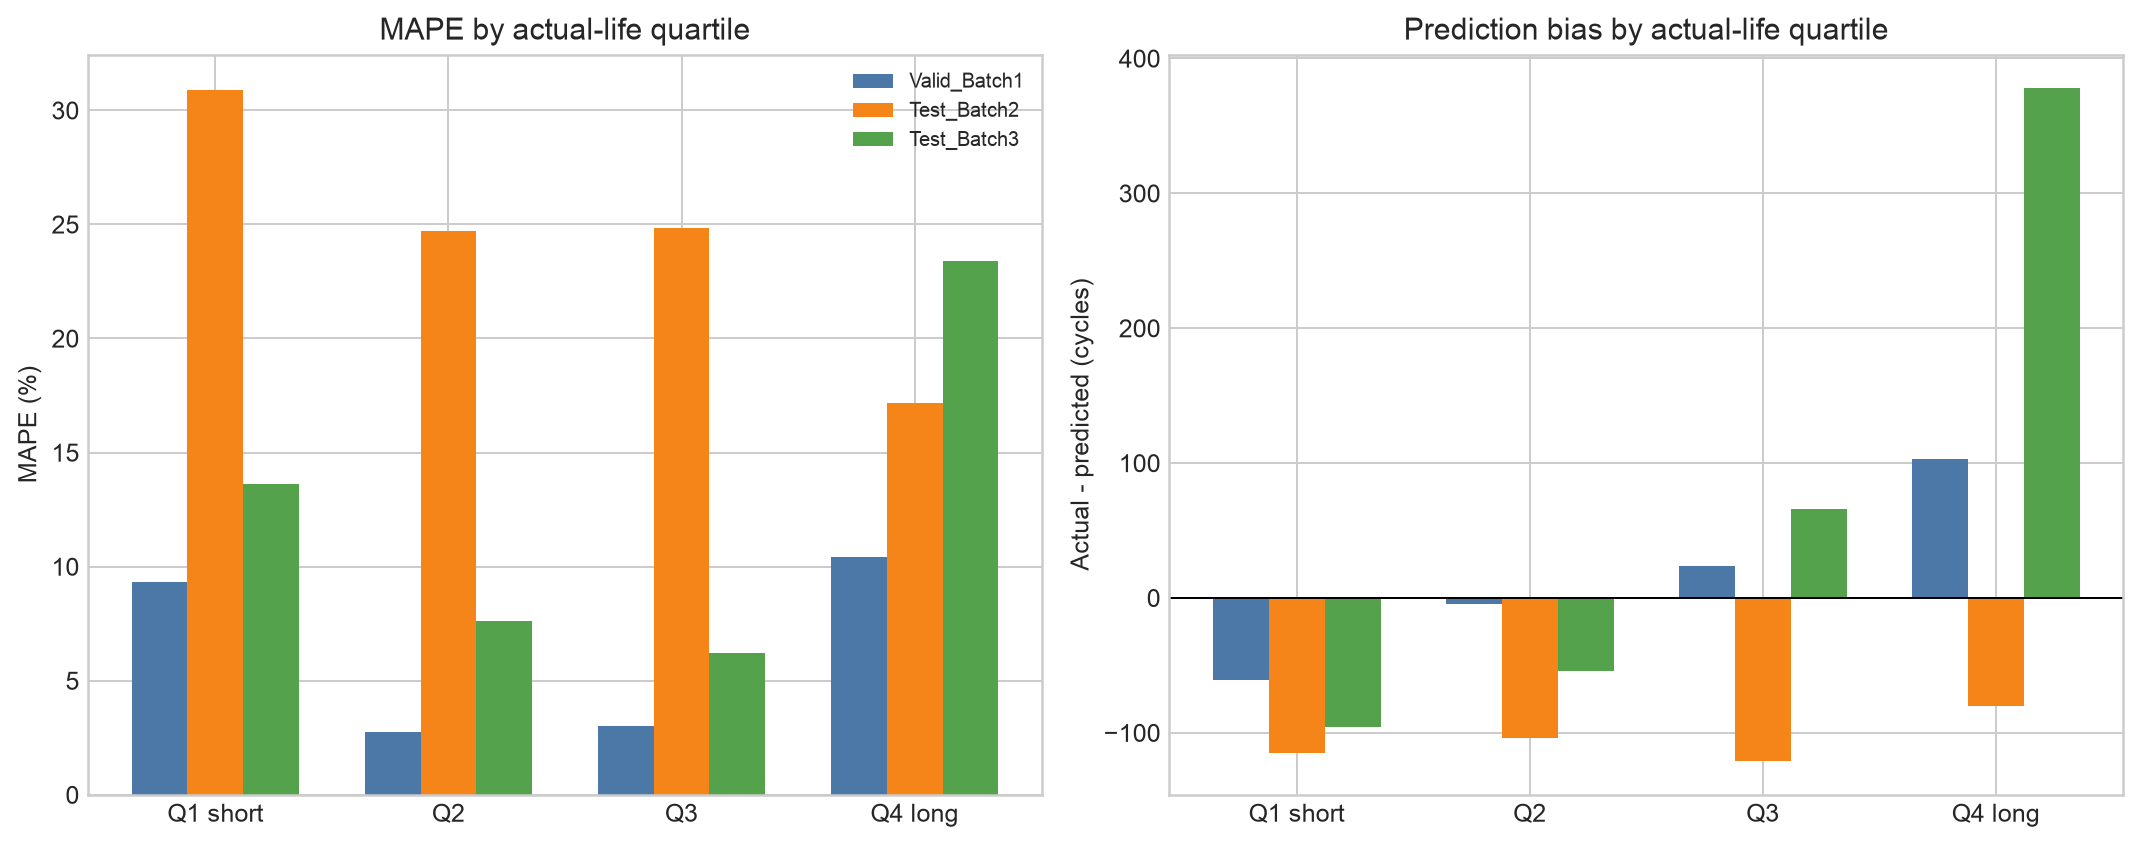

In [65]:
# 오류 분석용 예측 테이블
prediction_parts = []
for split, frame, prediction in [
    ('Valid_Batch1', batch1_valid, valid_prediction),
    ('Test_Batch2', batch2_day2, batch2_prediction),
    ('Test_Batch3', batch3_day2, batch3_prediction),
]:
    part = frame[['batch', 'cell_id', 'policy', 'cycle_life', 'dq_std']].copy()
    part['split'] = split
    part['prediction'] = prediction
    part['residual'] = part['cycle_life'] - part['prediction']
    part['APE'] = part['residual'].abs() / part['cycle_life']
    prediction_parts.append(part)
prediction_df_day2 = pd.concat(prediction_parts, ignore_index=True)

worst_cells = (
    prediction_df_day2.sort_values('APE', ascending=False)
    .groupby('split', as_index=False).head(5)
)
display(worst_cells[
    ['split', 'cell_id', 'policy', 'cycle_life', 'prediction', 'residual', 'APE']
].round(3))

# 재현 가능한 제출 결과 저장


# 핵심 피처의 배치 이동 확인
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
batch_frames = {'Batch 1': batch1_day2, 'Batch 2': batch2_day2, 'Batch 3': batch3_day2}
axes[0].boxplot(
    [frame['dq_std'] for frame in batch_frames.values()],
    tick_labels=list(batch_frames), showmeans=True
)
axes[0].set(title='Distribution shift in dq_std', ylabel='dq_std')
for batch_name, frame in batch_frames.items():
    axes[1].scatter(frame['dq_std'], frame['cycle_life'], alpha=.75, s=38,
                    label=batch_name)
axes[1].set_xscale('log')
axes[1].set(title='dq_std vs cycle life', xlabel='dq_std (log scale)',
            ylabel='Cycle life')
axes[1].legend()
fig.tight_layout()
fig.savefig(
    DAY2_FIGURE_DIR / '04_batch_shift.png',
    dpi=180, bbox_inches='tight', facecolor='white'
)
plt.show()

# 실제 수명 사분위별 MAPE와 예측 편향
quartile_parts = []
for split_name, group in prediction_df_day2.groupby('split'):
    group = group.copy()
    group['quartile'] = pd.qcut(
        group['cycle_life'], 4, labels=['Q1 short', 'Q2', 'Q3', 'Q4 long']
    )
    part = group.groupby('quartile', observed=True).agg(
        MAPE=('APE', 'mean'), bias=('residual', 'mean')
    ).reset_index()
    part['split'] = split_name
    quartile_parts.append(part)
quartile_error = pd.concat(quartile_parts, ignore_index=True)

split_colors = {
    'Valid_Batch1': '#4C78A8', 'Test_Batch2': '#F58518', 'Test_Batch3': '#54A24B'
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
x = np.arange(4)
width = .24
for i, (split_name, color) in enumerate(split_colors.items()):
    group = quartile_error[quartile_error['split'] == split_name]
    axes[0].bar(x + (i - 1) * width, group['MAPE'] * 100,
                width, label=split_name, color=color)
    axes[1].bar(x + (i - 1) * width, group['bias'], width,
                label=split_name, color=color)
for ax in axes:
    ax.set_xticks(x, ['Q1 short', 'Q2', 'Q3', 'Q4 long'])
axes[0].set(title='MAPE by actual-life quartile', ylabel='MAPE (%)')
axes[1].axhline(0, color='black', linewidth=.8)
axes[1].set(title='Prediction bias by actual-life quartile',
            ylabel='Actual - predicted (cycles)')
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(
    DAY2_FIGURE_DIR / '05_error_analysis.png',
    dpi=180, bbox_inches='tight', facecolor='white'
)
plt.show()

# CSV 결과도 같은 실행에서 갱신
performance_report.to_csv(DAY2_RESULT_DIR / 'model_performance.csv', index=False)
prediction_df_day2.to_csv(DAY2_RESULT_DIR / 'predictions.csv', index=False)
cv_search.to_csv(DAY2_RESULT_DIR / 'batch1_group_cv_search.csv', index=False)


## 7.4 오류 분석과 ESS 도메인 해석

### 오류 분석

- Batch 2는 `dq_std` 중앙값이 **0.0181**로 Batch 1의 **0.0121**보다 높고 수명이 400사이클대에 집중된다. 모델은 이 구간의 수명을 주로 과대예측하며, 가장 큰 오류는 실제 393사이클을 약 648사이클로 예측한 셀이다.
- Batch 3의 초장수명 셀은 반대로 과소예측한다. 실제 1,935사이클 셀을 약 1,044사이클로 예측했다. 학습 범위 밖의 장수명 영역에서 선형 Ridge가 평균 방향으로 수축하기 때문이다.
- 따라서 전체 MAPE 외에 **수명 구간별 MAPE·편향**과 피처 범위 이탈 여부를 운영 시 함께 감시해야 한다.

### ESS 활용

- 초기 100사이클의 `dq_std`가 큰 셀을 조기 선별하여 장수명 셀과 동일한 팩에 섞이지 않도록 팩 구성을 지원할 수 있다.
- 수명 예측치를 예방정비·교체 후보 우선순위 및 보증 리스크 관리에 사용할 수 있다.
- 단일 예측값으로 자동 폐기 결정을 내려서는 안 된다. Batch 2와 같은 새로운 충전정책에서는 오차가 크게 증가하므로 **배치/정책 OOD 경보와 사람의 검토**가 필요하다.

### 한계와 개선 방향

1. 학습 셀이 41개뿐이므로 복잡한 모델과 다수 피처가 불안정하다.
2. 현재 모델은 LFP/흑연 셀과 본 실험의 급속충전 범위에만 검증됐다.
3. Batch 2의 분포 이동을 줄이려면 해당 충전정책을 포함한 학습 데이터와 배치별 보정이 필요하다.
4. 향후에는 새로운 독립 배치를 추가하고, 예측구간 보정 및 OOD 감지기를 함께 평가한다.

> **최종 결론:** Batch 1 내부 성능은 논문 목표에 도달했지만 Batch 2의 외부 일반화에는 실패했다. 반면 Batch 3에서는 12.71%까지 회복됐다. 따라서 이 모델의 핵심 과제는 더 복잡한 알고리즘이 아니라 배치·충전정책 변화에 강한 데이터와 검증 설계이다.
